In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("../data/emi_prediction_dataset.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 404800
Columns: 27


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("../data/emi_prediction_dataset.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 404800
Columns: 27


In [7]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [9]:
print("Number of columns:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of columns: 27
1. age
2. gender
3. marital_status
4. education
5. monthly_salary
6. employment_type
7. years_of_employment
8. company_type
9. house_type
10. monthly_rent
11. family_size
12. dependents
13. school_fees
14. college_fees
15. travel_expenses
16. groceries_utilities
17. other_monthly_expenses
18. existing_loans
19. current_emi_amount
20. credit_score
21. bank_balance
22. emergency_fund
23. emi_scenario
24. requested_amount
25. requested_tenure
26. emi_eligibility
27. max_monthly_emi


In [10]:
missing = df.isnull().sum()

print(missing[missing > 0])

education         2404
monthly_rent      2426
credit_score      2420
bank_balance      2426
emergency_fund    2351
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print("=== EMI ELIGIBILITY ===")
print(df["emi_eligibility"].value_counts())

print("\n=== MAXIMUM MONTHLY EMI ===")
print(df["max_monthly_emi"].describe())

=== EMI ELIGIBILITY ===
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

=== MAXIMUM MONTHLY EMI ===
count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


In [13]:
print("AGE SAMPLE VALUES")
print(df["age"].value_counts(dropna=False).head(20))

print("\nMONTHLY SALARY SAMPLE VALUES")
print(df["monthly_salary"].value_counts(dropna=False).head(20))

AGE SAMPLE VALUES
age
38      119883
32       99924
48       80018
27       59556
58       40190
38.0       625
32.0       500
37         484
39         479
33         443
31         392
48.0       370
49         319
47         297
27.0       296
28         229
58.0       218
26         208
59         182
57         168
Name: count, dtype: int64

MONTHLY SALARY SAMPLE VALUES
monthly_salary
18000.0    4159
20000.0    2848
23400.0    2574
15000.0    2204
26000.0    1846
27000.0    1772
14400.0    1399
30000.0    1357
19500.0    1354
22500.0    1015
16000.0     929
12000.0     711
43300.0     701
36900.0     677
41000.0     672
39800.0     670
42300.0     666
39600.0     664
42000.0     664
43600.0     662
Name: count, dtype: int64


In [14]:
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "emi_scenario",
    "emi_eligibility"
]

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(column)
    print(df[column].value_counts(dropna=False))


gender
gender
Male      237427
Female    158351
MALE        1865
M           1843
male        1815
F           1171
female      1165
FEMALE      1163
Name: count, dtype: int64

marital_status
marital_status
Married    307837
Single      96963
Name: count, dtype: int64

education
education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
NaN                2404
Name: count, dtype: int64

employment_type
employment_type
Private          283099
Government        81167
Self-employed     40534
Name: count, dtype: int64

company_type
company_type
Large Indian    121139
MNC             101409
Mid-size        101301
Startup          60706
Small            20245
Name: count, dtype: int64

house_type
house_type
Rented    161601
Own       142307
Family    100892
Name: count, dtype: int64

existing_loans
existing_loans
No     243227
Yes    161573
Name: count, dtype: int64

emi_scenario
emi_scenario
Home Appliances EMI        80988
Personal Loan EMI  

In [1]:
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "emi_scenario",
    "emi_eligibility"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].dropna().unique())


gender:


NameError: name 'df' is not defined

In [3]:
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "emi_scenario",
    "emi_eligibility"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].dropna().unique())


gender:
['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']

marital_status:
['Married' 'Single']

education:
['Professional' 'Graduate' 'High School' 'Post Graduate']

employment_type:
['Private' 'Government' 'Self-employed']

company_type:
['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']

house_type:
['Rented' 'Family' 'Own']

existing_loans:
['Yes' 'No']

emi_scenario:
['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']

emi_eligibility:
['Not_Eligible' 'Eligible' 'High_Risk']


In [4]:
print("=== CREDIT SCORE ===")
print(df["credit_score"].describe())

print("\n=== YEARS OF EMPLOYMENT ===")
print(df["years_of_employment"].describe())

print("\n=== REQUESTED AMOUNT ===")
print(df["requested_amount"].describe())

print("\n=== REQUESTED TENURE ===")
print(df["requested_tenure"].describe())

print("\n=== MAX MONTHLY EMI ===")
print(df["max_monthly_emi"].describe())

=== CREDIT SCORE ===
count    402380.000000
mean        700.856223
std          88.435548
min           0.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64

=== YEARS OF EMPLOYMENT ===
count    404800.000000
mean          5.364079
std           6.079135
min           0.500000
25%           1.200000
50%           3.200000
75%           7.200000
max          36.000000
Name: years_of_employment, dtype: float64

=== REQUESTED AMOUNT ===
count    4.048000e+05
mean     3.708554e+05
std      3.451945e+05
min      1.000000e+04
25%      1.240000e+05
50%      2.360000e+05
75%      4.940000e+05
max      1.500000e+06
Name: requested_amount, dtype: float64

=== REQUESTED TENURE ===
count    404800.000000
mean         29.126677
std          18.100854
min           3.000000
25%          15.000000
50%          25.000000
75%          40.000000
max          84.000000
Name: requested_tenure, dtype: float64

=== MAX MONTHL

In [5]:
clean_df = df.copy()

print("Original rows:", len(df))
print("Cleaning dataframe created:", len(clean_df))

Original rows: 404800
Cleaning dataframe created: 404800


In [6]:
clean_df["age"] = pd.to_numeric(clean_df["age"], errors="coerce")

In [7]:
print(clean_df["age"].dtype)
print(clean_df["age"].isna().sum())
print(clean_df["age"].describe())

float64
3
count    404797.000000
mean         38.875832
std           9.303572
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64


In [8]:
clean_df["monthly_salary"] = pd.to_numeric(
    clean_df["monthly_salary"],
    errors="coerce"
)

In [9]:
print(clean_df["monthly_salary"].dtype)
print(clean_df["monthly_salary"].isna().sum())
print(clean_df["monthly_salary"].describe())

float64
1993
count    402807.000000
mean      59509.340498
std       43388.297878
min        3967.000000
25%       35400.000000
50%       51700.000000
75%       73000.000000
max      499970.000000
Name: monthly_salary, dtype: float64


In [10]:
gender_mapping = {
    "Male": "Male",
    "male": "Male",
    "MALE": "Male",
    "M": "Male",
    "Female": "Female",
    "female": "Female",
    "FEMALE": "Female",
    "F": "Female"
}

clean_df["gender"] = clean_df["gender"].map(gender_mapping)

In [11]:
print(clean_df["gender"].value_counts(dropna=False))

gender
Male      242950
Female    161850
Name: count, dtype: int64


In [12]:
print("Missing values after initial cleaning:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

Missing values after initial cleaning:
age                  3
education         2404
monthly_salary    1993
monthly_rent      2426
credit_score      2420
bank_balance      2426
emergency_fund    2351
dtype: int64


In [13]:
clean_df["education"] = clean_df["education"].fillna(
    clean_df["education"].mode()[0]
)

In [14]:
print(clean_df["education"].isnull().sum())

0


In [15]:
numeric_missing_columns = [
    "monthly_rent",
    "credit_score",
    "bank_balance",
    "emergency_fund"
]

for column in numeric_missing_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

TypeError: Cannot convert ['303200.0' '92500.0' '672100.0' ... '191600.0' '170400.0' '214400.0'] to numeric

In [16]:
for column in numeric_missing_columns:
    print(column, "→", clean_df[column].dtype)

monthly_rent → float64
credit_score → float64
bank_balance → object
emergency_fund → float64


In [17]:
numeric_missing_columns = [
    "monthly_rent",
    "credit_score",
    "bank_balance",
    "emergency_fund"
]

for column in numeric_missing_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

In [18]:
for column in numeric_missing_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

In [19]:
print(clean_df[numeric_missing_columns].isnull().sum())

monthly_rent      0
credit_score      0
bank_balance      0
emergency_fund    0
dtype: int64


In [20]:
print(clean_df[numeric_missing_columns].dtypes)

monthly_rent      float64
credit_score      float64
bank_balance      float64
emergency_fund    float64
dtype: object


In [21]:
print(clean_df[numeric_missing_columns].dtypes)
print(clean_df[numeric_missing_columns].isnull().sum())

monthly_rent      float64
credit_score      float64
bank_balance      float64
emergency_fund    float64
dtype: object
monthly_rent      0
credit_score      0
bank_balance      0
emergency_fund    0
dtype: int64


In [22]:
print("Age minimum:", clean_df["age"].min())
print("Age maximum:", clean_df["age"].max())

invalid_age = clean_df[
    (clean_df["age"] < 25) |
    (clean_df["age"] > 60)
]

print("Age outside expected range:", len(invalid_age))
print(invalid_age["age"].value_counts().head(20))

Age minimum: 26.0
Age maximum: 59.0
Age outside expected range: 0
Series([], Name: count, dtype: int64)


In [23]:
print("Salary minimum:", clean_df["monthly_salary"].min())
print("Salary maximum:", clean_df["monthly_salary"].max())

invalid_salary = clean_df[
    (clean_df["monthly_salary"] < 15000) |
    (clean_df["monthly_salary"] > 200000)
]

print("Salary outside expected range:", len(invalid_salary))
print(invalid_salary["monthly_salary"].describe())

Salary minimum: 3967.0
Salary maximum: 499970.0
Salary outside expected range: 10022
count     10022.000000
mean     149700.410597
std      189209.342284
min        3967.000000
25%        9847.250000
50%       14400.000000
75%      359138.250000
max      499970.000000
Name: monthly_salary, dtype: float64


In [24]:
print("Credit score minimum:", clean_df["credit_score"].min())
print("Credit score maximum:", clean_df["credit_score"].max())

invalid_credit = clean_df[
    (clean_df["credit_score"] < 300) |
    (clean_df["credit_score"] > 850)
]

print("Credit scores outside expected range:", len(invalid_credit))
print(invalid_credit["credit_score"].value_counts().head(20))

Credit score minimum: 0.0
Credit score maximum: 1200.0
Credit scores outside expected range: 4776
credit_score
1200.0    1628
999.0     1582
0.0       1566
Name: count, dtype: int64


In [25]:
print("=== REQUESTED AMOUNT ===")
print(clean_df["requested_amount"].describe())

print("\n=== REQUESTED TENURE ===")
print(clean_df["requested_tenure"].describe())

=== REQUESTED AMOUNT ===
count    4.048000e+05
mean     3.708554e+05
std      3.451945e+05
min      1.000000e+04
25%      1.240000e+05
50%      2.360000e+05
75%      4.940000e+05
max      1.500000e+06
Name: requested_amount, dtype: float64

=== REQUESTED TENURE ===
count    404800.000000
mean         29.126677
std          18.100854
min           3.000000
25%          15.000000
50%          25.000000
75%          40.000000
max          84.000000
Name: requested_tenure, dtype: float64


In [26]:
remaining_missing = clean_df.isnull().sum()

print(remaining_missing[remaining_missing > 0])

age                  3
monthly_salary    1993
dtype: int64


In [27]:
valid_credit_scores = clean_df[
    clean_df["credit_score"].between(300, 850)
]["credit_score"]

print("Valid credit score median:", valid_credit_scores.median())
print("Valid credit score mean:", valid_credit_scores.mean())

Valid credit score median: 701.0
Valid credit score mean: 700.3902990820551


In [28]:
low_salary = clean_df[
    clean_df["monthly_salary"] < 15000
]

high_salary = clean_df[
    clean_df["monthly_salary"] > 200000
]

print("Below ₹15,000:", len(low_salary))
print("Above ₹2,00,000:", len(high_salary))

Below ₹15,000: 6417
Above ₹2,00,000: 3605


In [29]:
print("LOW SALARY VALUES")
print(low_salary["monthly_salary"].describe())

print("\nHIGH SALARY VALUES")
print(high_salary["monthly_salary"].describe())

LOW SALARY VALUES
count     6417.000000
mean     10752.537946
std       3013.164580
min       3967.000000
25%       8203.000000
50%      11190.000000
75%      14300.000000
max      14914.000000
Name: monthly_salary, dtype: float64

HIGH SALARY VALUES
count      3605.000000
mean     397031.478225
std       62942.092862
min      200100.000000
25%      348088.000000
50%      399197.000000
75%      449691.000000
max      499970.000000
Name: monthly_salary, dtype: float64


In [30]:
print("Invalid salary:", len(invalid_salary))
print("Invalid credit score:", len(invalid_credit))

print("\nBoth salary AND credit score invalid:")

both_invalid = clean_df[
    ((clean_df["monthly_salary"] < 15000) |
     (clean_df["monthly_salary"] > 200000))
    &
    ((clean_df["credit_score"] < 300) |
     (clean_df["credit_score"] > 850))
]

print(len(both_invalid))

Invalid salary: 10022
Invalid credit score: 4776

Both salary AND credit score invalid:
97


In [31]:
# Identify valid credit scores
valid_credit = clean_df["credit_score"].between(300, 850)

print("Valid credit scores:", valid_credit.sum())
print("Invalid credit scores:", (~valid_credit).sum())

# Calculate median using ONLY valid scores
credit_median = clean_df.loc[valid_credit, "credit_score"].median()

print("Median valid credit score:", credit_median)

# Replace invalid values with NaN
clean_df.loc[~valid_credit, "credit_score"] = np.nan

# Fill invalid/missing scores with valid median
clean_df["credit_score"] = clean_df["credit_score"].fillna(credit_median)

print("Missing credit scores after cleaning:",
      clean_df["credit_score"].isnull().sum())

Valid credit scores: 400024
Invalid credit scores: 4776
Median valid credit score: 701.0
Missing credit scores after cleaning: 0


In [32]:
clean_df["salary_outlier"] = (
    (clean_df["monthly_salary"] < 15000) |
    (clean_df["monthly_salary"] > 200000)
)

print(clean_df["salary_outlier"].value_counts())

salary_outlier
False    394778
True      10022
Name: count, dtype: int64


In [33]:
clean_df["credit_score_cleaned"] = (
    clean_df["credit_score"]
)

In [34]:
print("Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

print("\nData types:")
print(clean_df[[
    "age",
    "monthly_salary",
    "credit_score"
]].dtypes)

Shape: (404800, 29)

Missing values:
age                  3
monthly_salary    1993
dtype: int64

Data types:
age               float64
monthly_salary    float64
credit_score      float64
dtype: object


In [35]:
print(clean_df["credit_score"].describe())

print(
    "Scores outside 300-850:",
    ((clean_df["credit_score"] < 300) |
     (clean_df["credit_score"] > 850)).sum()
)

count    404800.000000
mean        700.397493
std          67.262513
min         407.000000
25%         655.000000
50%         701.000000
75%         746.000000
max         850.000000
Name: credit_score, dtype: float64
Scores outside 300-850: 0


In [36]:
print(clean_df["gender"].value_counts())

gender
Male      242950
Female    161850
Name: count, dtype: int64


In [37]:
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "emi_scenario",
    "emi_eligibility"
]

for column in categorical_columns:
    print(f"{column}: {clean_df[column].unique()}")

gender: ['Female' 'Male']
marital_status: ['Married' 'Single']
education: ['Professional' 'Graduate' 'High School' 'Post Graduate']
employment_type: ['Private' 'Government' 'Self-employed']
company_type: ['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']
house_type: ['Rented' 'Family' 'Own']
existing_loans: ['Yes' 'No']
emi_scenario: ['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']
emi_eligibility: ['Not_Eligible' 'Eligible' 'High_Risk']


In [38]:
clean_df.to_csv(
    "../data/cleaned_emi_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [39]:
print(clean_df.shape)
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])
print(clean_df["credit_score"].describe())
print(clean_df["gender"].value_counts())

(404800, 29)
age                  3
monthly_salary    1993
dtype: int64
count    404800.000000
mean        700.397493
std          67.262513
min         407.000000
25%         655.000000
50%         701.000000
75%         746.000000
max         850.000000
Name: credit_score, dtype: float64
gender
Male      242950
Female    161850
Name: count, dtype: int64


In [40]:
# Check missing values
print("Missing age:", clean_df["age"].isnull().sum())
print("Missing monthly salary:", clean_df["monthly_salary"].isnull().sum())

# Convert to numeric
clean_df["age"] = pd.to_numeric(clean_df["age"], errors="coerce")
clean_df["monthly_salary"] = pd.to_numeric(clean_df["monthly_salary"], errors="coerce")

# Fill missing values using median
clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())
clean_df["monthly_salary"] = clean_df["monthly_salary"].fillna(
    clean_df["monthly_salary"].median()
)

# Final missing-value check
print("\nRemaining missing values:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

Missing age: 3
Missing monthly salary: 1993

Remaining missing values:
Series([], dtype: int64)


In [41]:
print("Dataset shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum().sum())

print("\nAge range:")
print(clean_df["age"].min(), "to", clean_df["age"].max())

print("\nMonthly salary range:")
print(clean_df["monthly_salary"].min(), "to", clean_df["monthly_salary"].max())

print("\nCredit score range:")
print(clean_df["credit_score"].min(), "to", clean_df["credit_score"].max())

print("\nGender:")
print(clean_df["gender"].value_counts())

print("\nEMI eligibility:")
print(clean_df["emi_eligibility"].value_counts())

print("\nSalary outliers:")
print(clean_df["salary_outlier"].value_counts())

Dataset shape: (404800, 29)

Missing values:
0

Age range:
26.0 to 59.0

Monthly salary range:
3967.0 to 499970.0

Credit score range:
407.0 to 850.0

Gender:
gender
Male      242950
Female    161850
Name: count, dtype: int64

EMI eligibility:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

Salary outliers:
salary_outlier
False    394778
True      10022
Name: count, dtype: int64


In [42]:
clean_df.to_csv("../data/cleaned_emi_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# EMI Eligibility distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x="emi_eligibility")

plt.title("EMI Eligibility Distribution")
plt.xlabel("EMI Eligibility")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Seaborn imported successfully!")

Seaborn imported successfully!


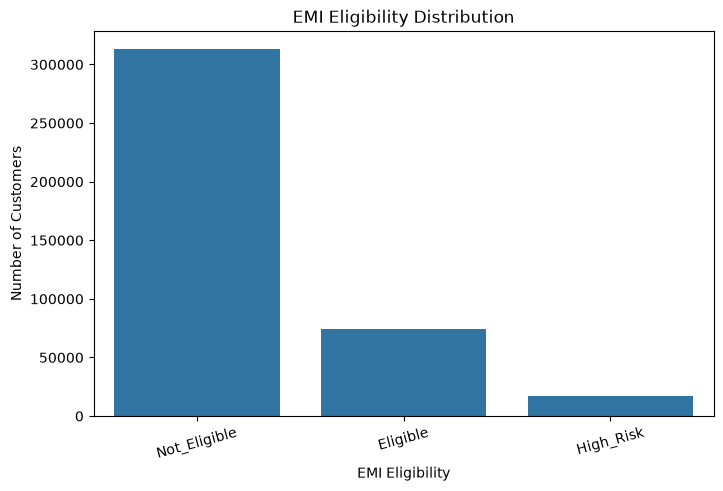

In [45]:
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x="emi_eligibility")

plt.title("EMI Eligibility Distribution")
plt.xlabel("EMI Eligibility")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

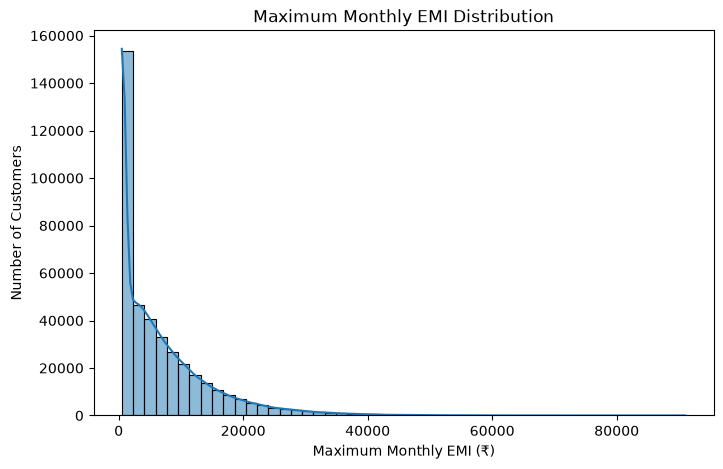

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["max_monthly_emi"], bins=50, kde=True)

plt.title("Maximum Monthly EMI Distribution")
plt.xlabel("Maximum Monthly EMI (₹)")
plt.ylabel("Number of Customers")
plt.show()

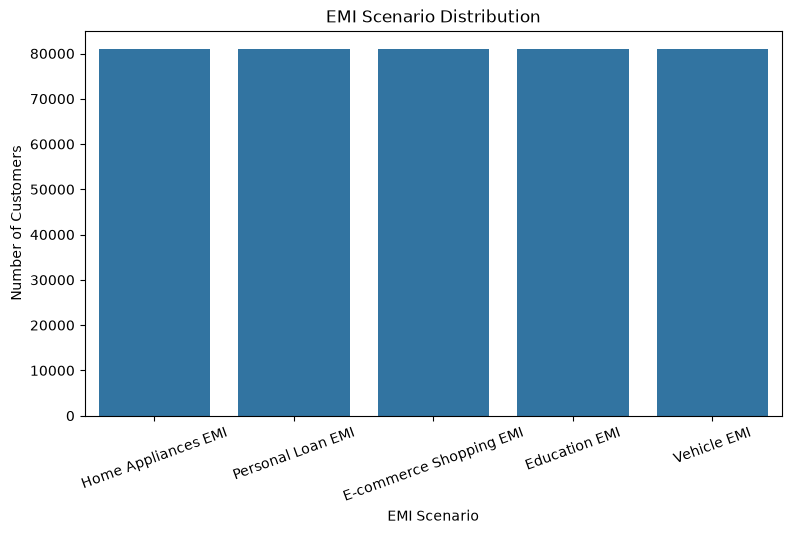

In [47]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=clean_df,
    x="emi_scenario",
    order=clean_df["emi_scenario"].value_counts().index
)

plt.title("EMI Scenario Distribution")
plt.xlabel("EMI Scenario")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

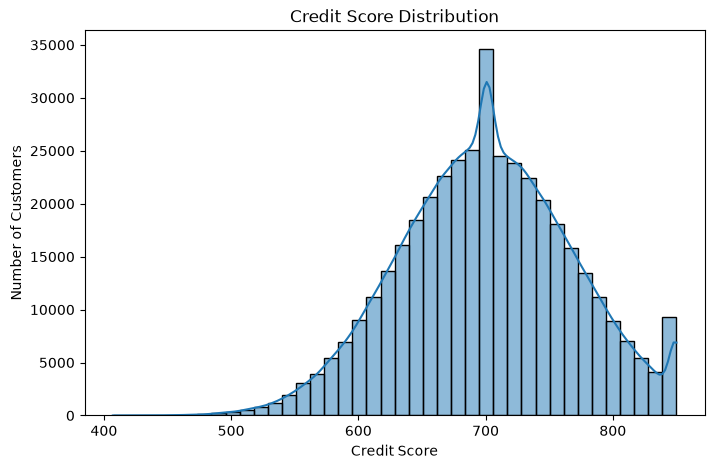

In [48]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["credit_score"],
    bins=40,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

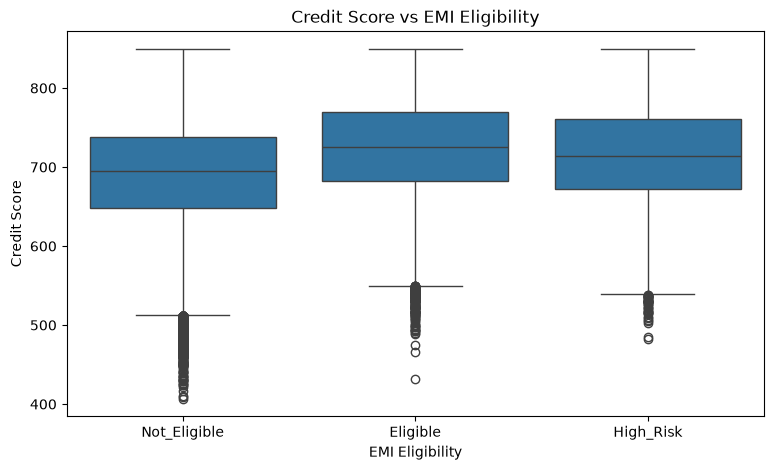

In [49]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="credit_score"
)

plt.title("Credit Score vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Credit Score")
plt.show()

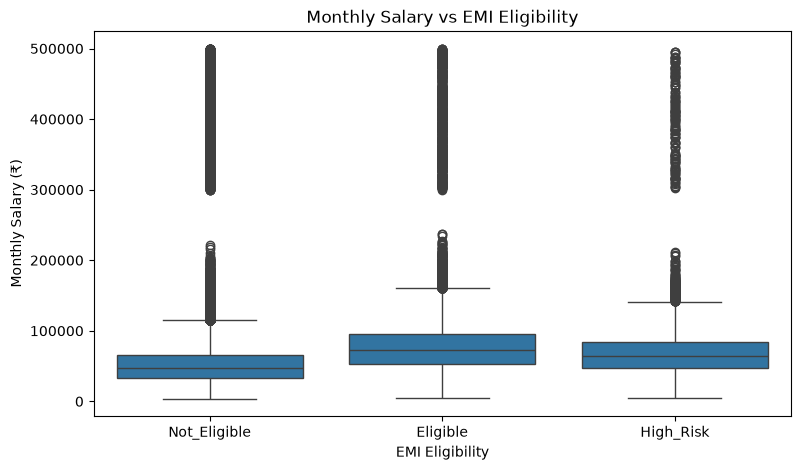

In [50]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="monthly_salary"
)

plt.title("Monthly Salary vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Monthly Salary (₹)")
plt.show()

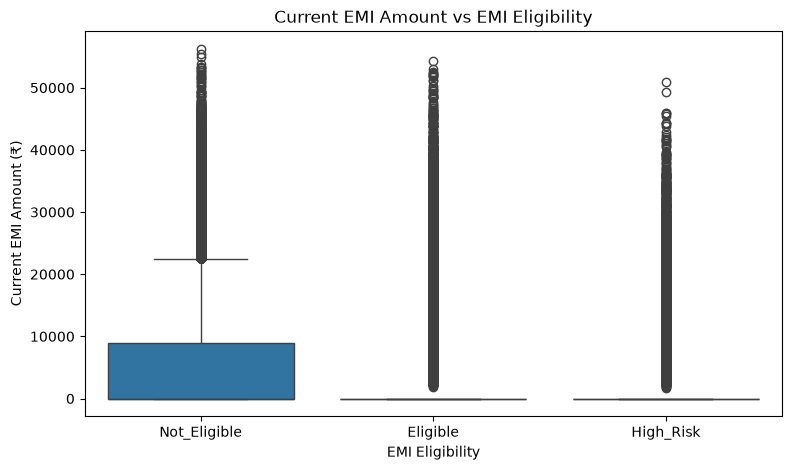

In [51]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="current_emi_amount"
)

plt.title("Current EMI Amount vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Current EMI Amount (₹)")
plt.show()

In [52]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

clean_df["total_monthly_expenses"] = clean_df[expense_columns].sum(axis=1)

print(clean_df["total_monthly_expenses"].describe())

count    404800.000000
mean      40096.152490
std       20307.683573
min        3400.000000
25%       25300.000000
50%       36700.000000
75%       51100.000000
max      207500.000000
Name: total_monthly_expenses, dtype: float64


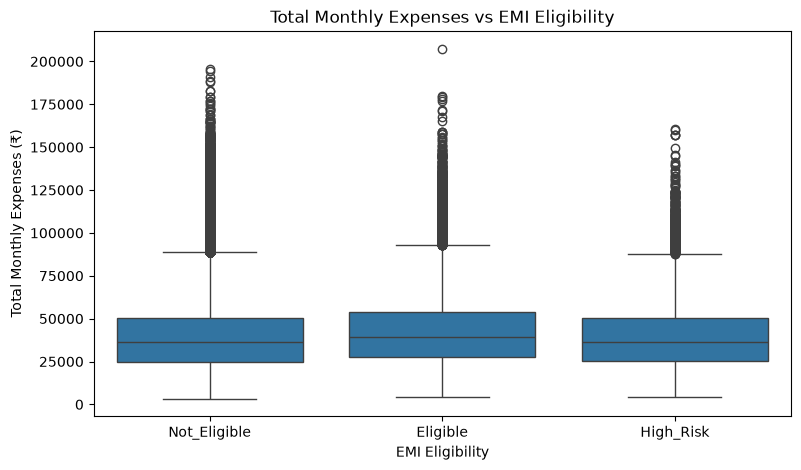

In [53]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="total_monthly_expenses"
)

plt.title("Total Monthly Expenses vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Total Monthly Expenses (₹)")
plt.show()

In [54]:
clean_df["expense_to_income"] = (
    clean_df["total_monthly_expenses"] /
    clean_df["monthly_salary"]
)

print(clean_df["expense_to_income"].describe())

count    404800.000000
mean          0.783593
std           0.577810
min           0.011144
25%           0.530233
50%           0.700569
75%           0.889184
max          26.776607
Name: expense_to_income, dtype: float64


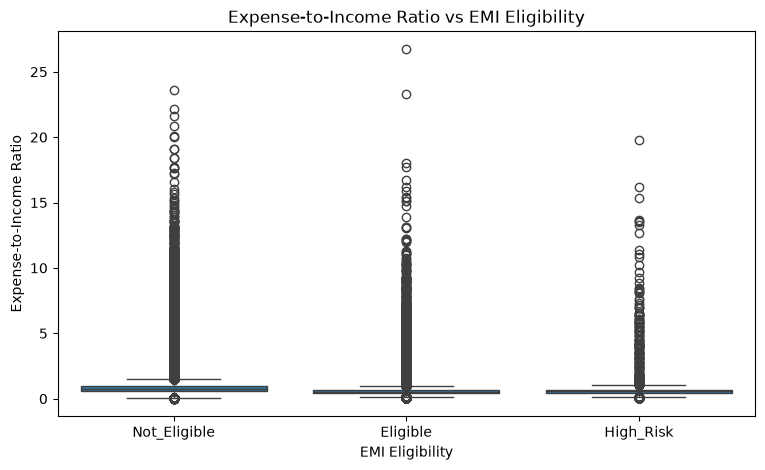

In [55]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="expense_to_income"
)

plt.title("Expense-to-Income Ratio vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Expense-to-Income Ratio")
plt.show()

In [56]:
clean_df["disposable_income"] = (
    clean_df["monthly_salary"]
    - clean_df["total_monthly_expenses"]
    - clean_df["current_emi_amount"]
)

print(clean_df["disposable_income"].describe())

count    404800.000000
mean      14831.331744
std       37581.517747
min     -161883.000000
25%         400.000000
50%       10600.000000
75%       22400.000000
max      485540.000000
Name: disposable_income, dtype: float64


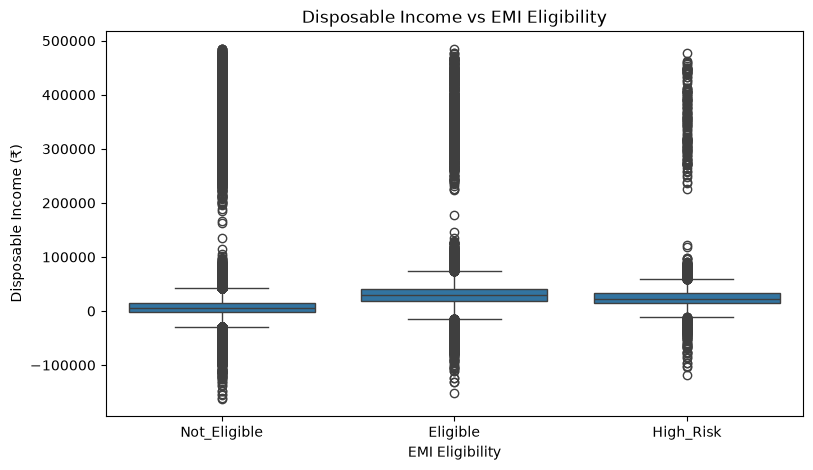

In [57]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="disposable_income"
)

plt.title("Disposable Income vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Disposable Income (₹)")
plt.show()

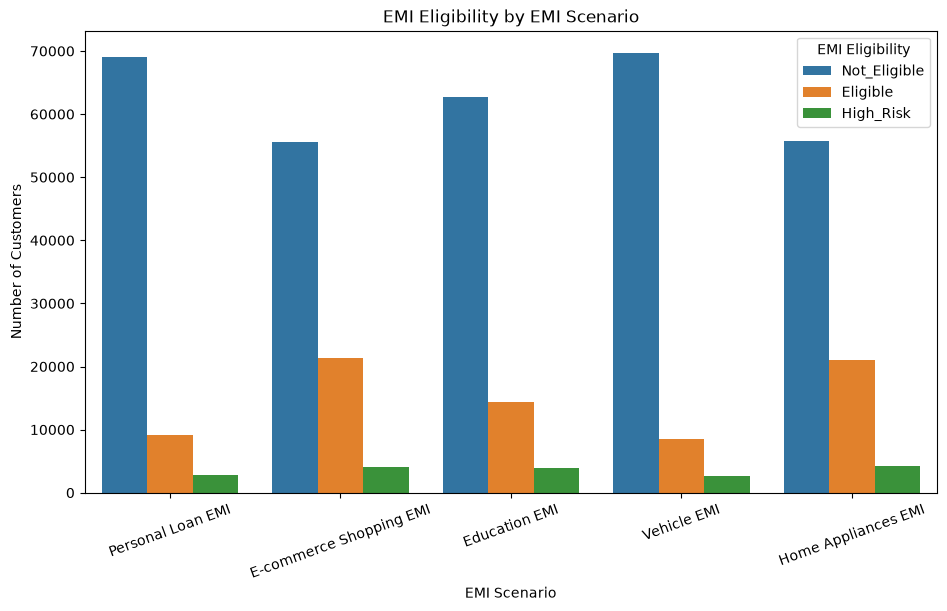

In [58]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=clean_df,
    x="emi_scenario",
    hue="emi_eligibility"
)

plt.title("EMI Eligibility by EMI Scenario")
plt.xlabel("EMI Scenario")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="EMI Eligibility")
plt.show()

In [59]:
scenario_eligibility = pd.crosstab(
    clean_df["emi_scenario"],
    clean_df["emi_eligibility"],
    normalize="index"
) * 100

print(scenario_eligibility.round(2))

emi_eligibility          Eligible  High_Risk  Not_Eligible
emi_scenario                                              
E-commerce Shopping EMI     26.32       4.95         68.74
Education EMI               17.73       4.76         77.50
Home Appliances EMI         26.00       5.19         68.81
Personal Loan EMI           11.34       3.42         85.25
Vehicle EMI                 10.56       3.29         86.15


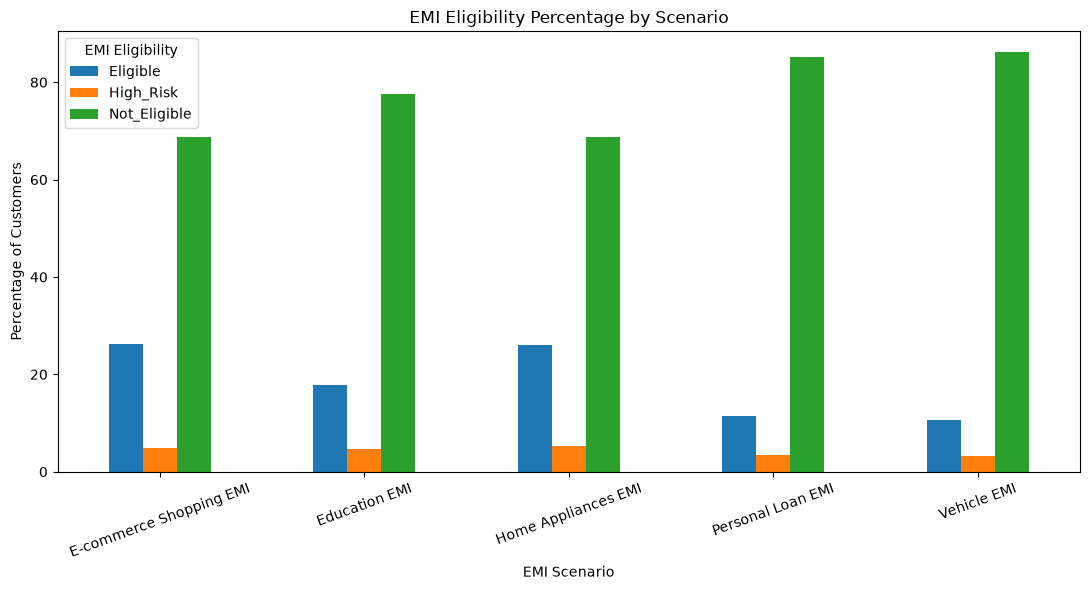

In [60]:
scenario_eligibility.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("EMI Eligibility Percentage by Scenario")
plt.xlabel("EMI Scenario")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=20)
plt.legend(title="EMI Eligibility")
plt.tight_layout()
plt.show()

In [61]:
numeric_columns = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "total_monthly_expenses",
    "expense_to_income",
    "disposable_income",
    "max_monthly_emi"
]

correlation_matrix = clean_df[numeric_columns].corr()

print(
    correlation_matrix["max_monthly_emi"]
    .sort_values(ascending=False)
)

max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.456028
travel_expenses           0.440948
disposable_income         0.423534
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.378284
credit_score              0.299086
total_monthly_expenses    0.106481
years_of_employment       0.028887
requested_tenure          0.001006
age                      -0.000848
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.169423
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
expense_to_income        -0.266512
Name: max_monthly_emi, dtype: float64


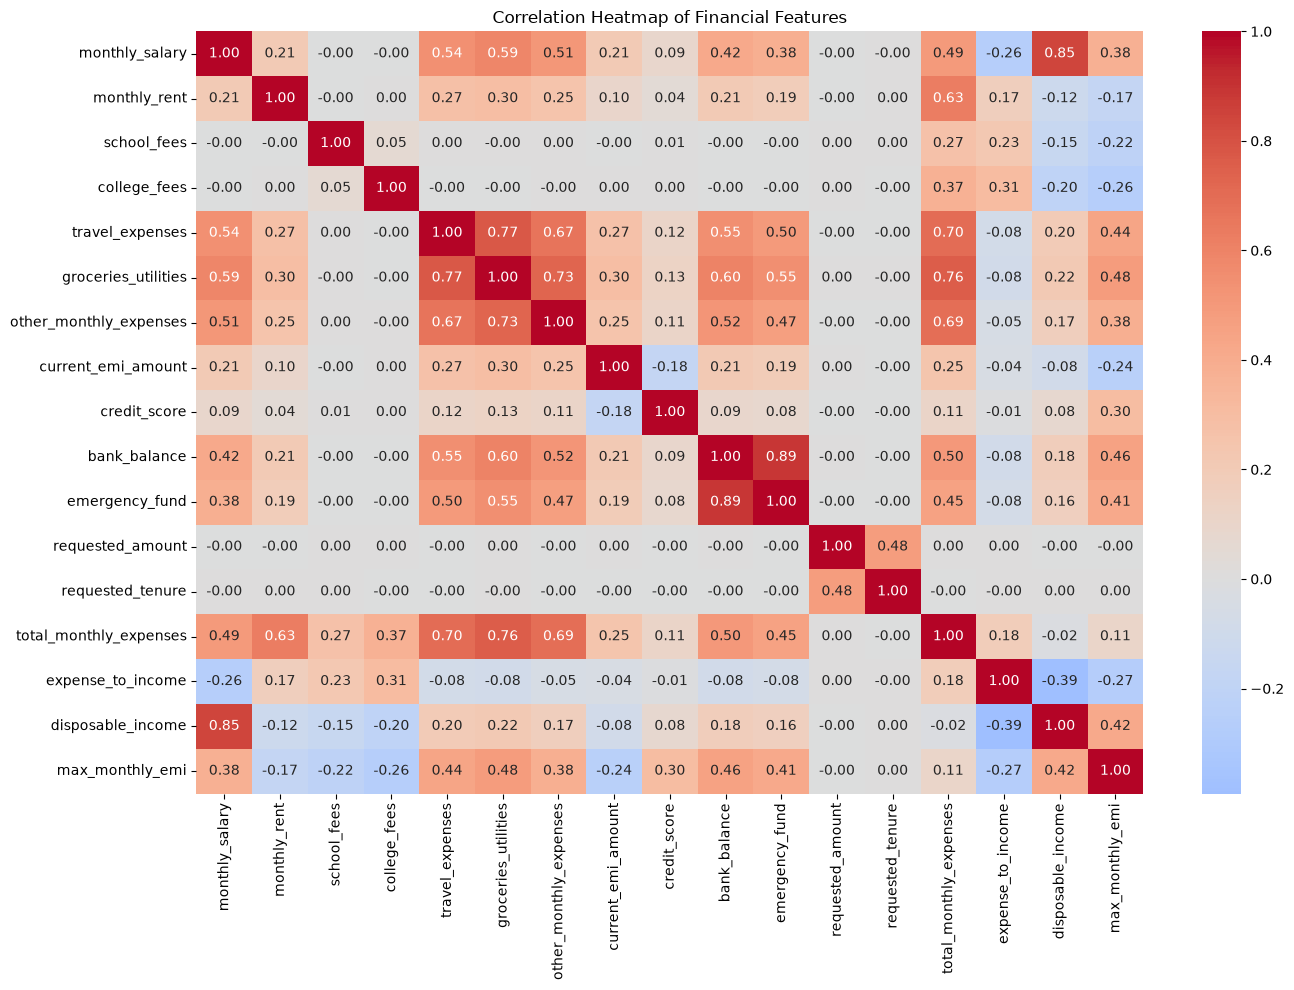

In [62]:
heatmap_columns = [
    "monthly_salary",
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "total_monthly_expenses",
    "expense_to_income",
    "disposable_income",
    "max_monthly_emi"
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    clean_df[heatmap_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Financial Features")
plt.tight_layout()
plt.show()

In [63]:
clean_df["emi_to_income"] = (
    clean_df["current_emi_amount"] /
    clean_df["monthly_salary"]
)

print(clean_df["emi_to_income"].describe())

count    404800.000000
mean          0.083594
std           0.142263
min           0.000000
25%           0.000000
50%           0.000000
75%           0.174422
max           7.704465
Name: emi_to_income, dtype: float64


In [64]:
clean_df["savings_ratio"] = (
    clean_df["emergency_fund"] /
    clean_df["monthly_salary"]
)

print(clean_df["savings_ratio"].describe())

count    404800.000000
mean          1.779785
std           1.722768
min           0.004762
25%           0.853419
50%           1.542789
75%           2.395833
max          90.129630
Name: savings_ratio, dtype: float64


In [65]:
clean_df["bank_balance_to_income"] = (
    clean_df["bank_balance"] /
    clean_df["monthly_salary"]
)

print(clean_df["bank_balance_to_income"].describe())

count    404800.000000
mean          4.448338
std           3.959213
min           0.020562
25%           2.345000
50%           4.235848
75%           6.143676
max         218.462139
Name: bank_balance_to_income, dtype: float64


In [1]:
ratio_columns = [
    "emi_to_income",
    "savings_ratio",
    "bank_balance_to_income"
]

for column in ratio_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print("95th percentile :", clean_df[column].quantile(0.95))
    print("99th percentile :", clean_df[column].quantile(0.99))
    print("99.5th percentile:", clean_df[column].quantile(0.995))
    print("99.9th percentile:", clean_df[column].quantile(0.999))
    print("Values > 1:", (clean_df[column] > 1).sum())
    print("Values > 5:", (clean_df[column] > 5).sum())
    print("Values > 10:", (clean_df[column] > 10).sum())


emi_to_income


NameError: name 'clean_df' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

clean_df = pd.read_csv("../data/cleaned_emi_dataset.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", clean_df.shape)

Cleaned dataset loaded successfully!
Shape: (404800, 29)


In [3]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

clean_df["total_monthly_expenses"] = clean_df[expense_columns].sum(axis=1)

clean_df["expense_to_income"] = (
    clean_df["total_monthly_expenses"] /
    clean_df["monthly_salary"]
)

clean_df["disposable_income"] = (
    clean_df["monthly_salary"]
    - clean_df["total_monthly_expenses"]
    - clean_df["current_emi_amount"]
)

clean_df["emi_to_income"] = (
    clean_df["current_emi_amount"] /
    clean_df["monthly_salary"]
)

clean_df["savings_ratio"] = (
    clean_df["emergency_fund"] /
    clean_df["monthly_salary"]
)

clean_df["bank_balance_to_income"] = (
    clean_df["bank_balance"] /
    clean_df["monthly_salary"]
)

print("Features recreated successfully!")
print("Shape:", clean_df.shape)

Features recreated successfully!
Shape: (404800, 35)


In [4]:
ratio_columns = [
    "emi_to_income",
    "savings_ratio",
    "bank_balance_to_income"
]

for column in ratio_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print("95th percentile :", clean_df[column].quantile(0.95))
    print("99th percentile :", clean_df[column].quantile(0.99))
    print("99.5th percentile:", clean_df[column].quantile(0.995))
    print("99.9th percentile:", clean_df[column].quantile(0.999))
    print("Values > 1:", (clean_df[column] > 1).sum())
    print("Values > 5:", (clean_df[column] > 5).sum())
    print("Values > 10:", (clean_df[column] > 10).sum())


emi_to_income
95th percentile : 0.2762096774193548
99th percentile : 0.296998420221169
99.5th percentile: 0.29979881259946267
99.9th percentile: 1.6856452657682772
Values > 1: 847
Values > 5: 9
Values > 10: 0

savings_ratio
95th percentile : 3.728465039561475
99th percentile : 4.514815181518152
99.5th percentile: 7.894131157462044
99.9th percentile: 24.289133414432392
Values > 1: 281909
Values > 5: 2757
Values > 10: 1647

bank_balance_to_income
95th percentile : 7.688442211055277
99th percentile : 7.99816015784277
99.5th percentile: 20.85073431357024
99.9th percentile: 58.77462230882942
Values > 1: 375470
Values > 5: 161711
Values > 10: 3311


In [5]:
clean_df["total_financial_burden"] = (
    clean_df["expense_to_income"] +
    clean_df["emi_to_income"]
)

print(clean_df["total_financial_burden"].describe())

count    404800.000000
mean          0.867187
std           0.636534
min           0.011144
25%           0.606769
50%           0.779123
75%           0.991204
max          31.291979
Name: total_financial_burden, dtype: float64


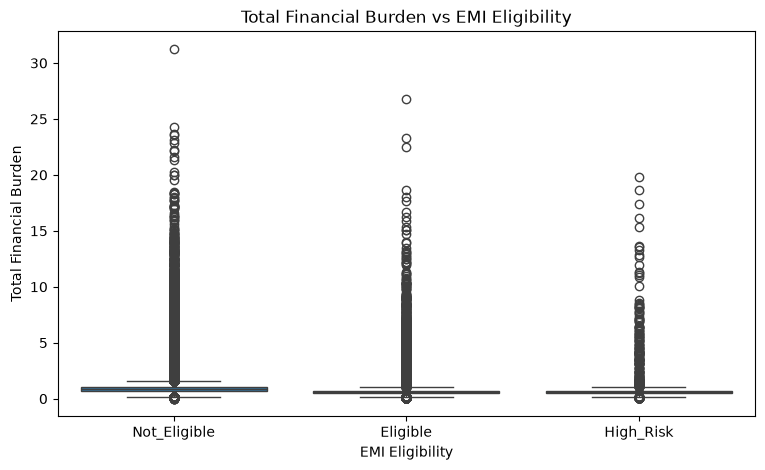

In [6]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="emi_eligibility",
    y="total_financial_burden"
)

plt.title("Total Financial Burden vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Total Financial Burden")
plt.show()

In [1]:
print("Number of columns:", len(clean_df.columns))

for i, column in enumerate(clean_df.columns, start=1):
    print(i, ":", column)

NameError: name 'clean_df' is not defined

In [2]:
import pandas as pd
import numpy as np

clean_df = pd.read_csv("../data/cleaned_emi_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", clean_df.shape)

Dataset loaded successfully!
Shape: (404800, 29)


In [3]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

clean_df["total_monthly_expenses"] = clean_df[expense_columns].sum(axis=1)

clean_df["expense_to_income"] = (
    clean_df["total_monthly_expenses"] /
    clean_df["monthly_salary"]
)

clean_df["disposable_income"] = (
    clean_df["monthly_salary"]
    - clean_df["total_monthly_expenses"]
    - clean_df["current_emi_amount"]
)

clean_df["emi_to_income"] = (
    clean_df["current_emi_amount"] /
    clean_df["monthly_salary"]
)

clean_df["savings_ratio"] = (
    clean_df["emergency_fund"] /
    clean_df["monthly_salary"]
)

clean_df["bank_balance_to_income"] = (
    clean_df["bank_balance"] /
    clean_df["monthly_salary"]
)

clean_df["total_financial_burden"] = (
    clean_df["expense_to_income"] +
    clean_df["emi_to_income"]
)

print("Feature engineering variables recreated!")
print("Shape:", clean_df.shape)

Feature engineering variables recreated!
Shape: (404800, 36)


In [4]:
print("Number of columns:", len(clean_df.columns))

for i, column in enumerate(clean_df.columns, start=1):
    print(i, ":", column)

Number of columns: 36
1 : age
2 : gender
3 : marital_status
4 : education
5 : monthly_salary
6 : employment_type
7 : years_of_employment
8 : company_type
9 : house_type
10 : monthly_rent
11 : family_size
12 : dependents
13 : school_fees
14 : college_fees
15 : travel_expenses
16 : groceries_utilities
17 : other_monthly_expenses
18 : existing_loans
19 : current_emi_amount
20 : credit_score
21 : bank_balance
22 : emergency_fund
23 : emi_scenario
24 : requested_amount
25 : requested_tenure
26 : emi_eligibility
27 : max_monthly_emi
28 : salary_outlier
29 : credit_score_cleaned
30 : total_monthly_expenses
31 : expense_to_income
32 : disposable_income
33 : emi_to_income
34 : savings_ratio
35 : bank_balance_to_income
36 : total_financial_burden


In [5]:
print("Number of columns:", len(clean_df.columns))

for i, column in enumerate(clean_df.columns, start=1):
    print(i, ":", column)

Number of columns: 36
1 : age
2 : gender
3 : marital_status
4 : education
5 : monthly_salary
6 : employment_type
7 : years_of_employment
8 : company_type
9 : house_type
10 : monthly_rent
11 : family_size
12 : dependents
13 : school_fees
14 : college_fees
15 : travel_expenses
16 : groceries_utilities
17 : other_monthly_expenses
18 : existing_loans
19 : current_emi_amount
20 : credit_score
21 : bank_balance
22 : emergency_fund
23 : emi_scenario
24 : requested_amount
25 : requested_tenure
26 : emi_eligibility
27 : max_monthly_emi
28 : salary_outlier
29 : credit_score_cleaned
30 : total_monthly_expenses
31 : expense_to_income
32 : disposable_income
33 : emi_to_income
34 : savings_ratio
35 : bank_balance_to_income
36 : total_financial_burden


In [6]:
classification_drop_columns = [
    "emi_eligibility",
    "max_monthly_emi",
    "credit_score_cleaned"
]

X_classification = clean_df.drop(
    columns=classification_drop_columns
)

y_classification = clean_df["emi_eligibility"]

print("Classification X shape:", X_classification.shape)
print("Classification y shape:", y_classification.shape)

print("\nTarget distribution:")
print(y_classification.value_counts())

print("\nNumber of classification features:",
      X_classification.shape[1])

Classification X shape: (404800, 33)
Classification y shape: (404800,)

Target distribution:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

Number of classification features: 33


In [7]:
regression_drop_columns = [
    "max_monthly_emi",
    "emi_eligibility",
    "credit_score_cleaned"
]

X_regression = clean_df.drop(
    columns=regression_drop_columns
)

y_regression = clean_df["max_monthly_emi"]

print("Regression X shape:", X_regression.shape)
print("Regression y shape:", y_regression.shape)

print("\nRegression target statistics:")
print(y_regression.describe())

print("\nNumber of regression features:",
      X_regression.shape[1])

Regression X shape: (404800, 33)
Regression y shape: (404800,)

Regression target statistics:
count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

Number of regression features: 33


In [8]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Classification training shape:", X_train_cls.shape)
print("Classification testing shape:", X_test_cls.shape)

print("\nTraining target distribution:")
print(y_train_cls.value_counts())

print("\nTesting target distribution:")
print(y_test_cls.value_counts())

Classification training shape: (323840, 33)
Classification testing shape: (80960, 33)

Training target distribution:
emi_eligibility
Not_Eligible    250294
Eligible         59555
High_Risk        13991
Name: count, dtype: int64

Testing target distribution:
emi_eligibility
Not_Eligible    62574
Eligible        14889
High_Risk        3497
Name: count, dtype: int64


In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_train_reg.shape)
print("Regression testing shape:", X_test_reg.shape)

print("\nTraining target statistics:")
print(y_train_reg.describe())

print("\nTesting target statistics:")
print(y_test_reg.describe())

Regression training shape: (323840, 33)
Regression testing shape: (80960, 33)

Training target statistics:
count    323840.000000
mean       6770.019742
std        7755.619398
min         500.000000
25%         500.000000
50%        4200.000000
75%        9800.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

Testing target statistics:
count    80960.000000
mean      6737.931811
std       7683.564797
min        500.000000
25%        500.000000
50%       4228.000000
75%       9750.000000
max      77319.000000
Name: max_monthly_emi, dtype: float64


In [10]:
# Identify numerical and categorical columns

numerical_columns = X_train_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train_reg.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_columns)

print("\nNumber of numerical features:", len(numerical_columns))

print("\nCategorical features:")
print(categorical_columns)

print("\nNumber of categorical features:", len(categorical_columns))

Numerical features:
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'total_monthly_expenses', 'expense_to_income', 'disposable_income', 'emi_to_income', 'savings_ratio', 'bank_balance_to_income', 'total_financial_burden']

Number of numerical features: 24

Categorical features:
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']

Number of categorical features: 8


In [1]:
# Check all feature data types

print(X_train_reg.dtypes)

print("\nColumns not classified as numerical or categorical:")

classified_columns = numerical_columns + categorical_columns

print(
    X_train_reg.columns[
        ~X_train_reg.columns.isin(classified_columns)
    ].tolist()
)

NameError: name 'X_train_reg' is not defined

In [2]:
import pandas as pd

# Load the cleaned dataset
clean_df = pd.read_csv("../data/cleaned_emi_dataset.csv")

print("Dataset shape:", clean_df.shape)
print(clean_df.head())

Dataset shape: (404800, 29)
    age  gender marital_status     education  monthly_salary employment_type  \
0  38.0  Female        Married  Professional         82600.0         Private   
1  38.0  Female        Married      Graduate         21500.0         Private   
2  38.0    Male        Married  Professional         86100.0         Private   
3  58.0  Female        Married   High School         66800.0         Private   
4  48.0  Female        Married  Professional         57300.0         Private   

   years_of_employment company_type house_type  monthly_rent  ...  \
0                  0.9     Mid-size     Rented       20000.0  ...   
1                  7.0          MNC     Family           0.0  ...   
2                  5.8      Startup        Own           0.0  ...   
3                  2.2     Mid-size        Own           0.0  ...   
4                  3.4     Mid-size     Family           0.0  ...   

   credit_score  bank_balance  emergency_fund             emi_scenario  \
0 

In [3]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

clean_df["total_monthly_expenses"] = clean_df[expense_columns].sum(axis=1)

clean_df["expense_to_income"] = (
    clean_df["total_monthly_expenses"] / clean_df["monthly_salary"]
)

clean_df["disposable_income"] = (
    clean_df["monthly_salary"]
    - clean_df["total_monthly_expenses"]
    - clean_df["current_emi_amount"]
)

clean_df["emi_to_income"] = (
    clean_df["current_emi_amount"] / clean_df["monthly_salary"]
)

clean_df["savings_ratio"] = (
    clean_df["emergency_fund"] / clean_df["monthly_salary"]
)

clean_df["bank_balance_to_income"] = (
    clean_df["bank_balance"] / clean_df["monthly_salary"]
)

clean_df["total_financial_burden"] = (
    clean_df["expense_to_income"] + clean_df["emi_to_income"]
)

print("Shape after feature engineering:", clean_df.shape)

Shape after feature engineering: (404800, 36)


In [4]:
regression_drop_columns = [
    "max_monthly_emi",
    "emi_eligibility",
    "credit_score_cleaned"
]

X_regression = clean_df.drop(columns=regression_drop_columns)
y_regression = clean_df["max_monthly_emi"]

print("X shape:", X_regression.shape)
print("y shape:", y_regression.shape)

X shape: (404800, 33)
y shape: (404800,)


In [5]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_train_reg.shape)
print("Regression testing shape:", X_test_reg.shape)

Regression training shape: (323840, 33)
Regression testing shape: (80960, 33)


In [6]:
print(X_train_reg.dtypes)

print("\nColumns not classified as numerical or categorical:")

classified_columns = numerical_columns + categorical_columns

print(
    X_train_reg.columns[
        ~X_train_reg.columns.isin(classified_columns)
    ].tolist()
)

age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
salary_outlier               bool
total_monthly_expenses    float64
expense_to_income         float64
disposable_income         float64
emi_to_income 

NameError: name 'numerical_columns' is not defined

In [7]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_train_reg.shape)
print("Regression testing shape:", X_test_reg.shape)


# Identify numerical and categorical columns
numerical_columns = X_train_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train_reg.select_dtypes(
    include=["object"]
).columns.tolist()


# Display data types
print("\nData types:")
print(X_train_reg.dtypes)

print("\nNumber of numerical features:", len(numerical_columns))
print("Number of categorical features:", len(categorical_columns))

print("\nColumns not classified as numerical or categorical:")

classified_columns = numerical_columns + categorical_columns

remaining_columns = X_train_reg.columns[
    ~X_train_reg.columns.isin(classified_columns)
].tolist()

print(remaining_columns)

Regression training shape: (323840, 33)
Regression testing shape: (80960, 33)

Data types:
age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
salary_outlier               bool
total_monthly_expenses   

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Boolean feature
boolean_columns = ["salary_outlier"]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Boolean preprocessing
boolean_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine all preprocessing steps
preprocessor_reg = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("bool", boolean_pipeline, boolean_columns)
])

print("Regression preprocessing pipeline created successfully!")

Regression preprocessing pipeline created successfully!


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Create Linear Regression pipeline
linear_regression_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

# Train the model
linear_regression_model.fit(
    X_train_reg,
    y_train_reg
)

print("Linear Regression model trained successfully!")

ValueError: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.

In [10]:
# Convert Boolean feature to numeric
X_train_reg = X_train_reg.copy()
X_test_reg = X_test_reg.copy()

X_train_reg["salary_outlier"] = X_train_reg["salary_outlier"].astype(int)
X_test_reg["salary_outlier"] = X_test_reg["salary_outlier"].astype(int)

print(X_train_reg["salary_outlier"].value_counts())
print("\nData type:", X_train_reg["salary_outlier"].dtype)

salary_outlier
0    315831
1      8009
Name: count, dtype: int64

Data type: int64


In [11]:
# Add salary_outlier to numerical features
if "salary_outlier" not in numerical_columns:
    numerical_columns.append("salary_outlier")

print("Number of numerical features:", len(numerical_columns))
print("Number of categorical features:", len(categorical_columns))

Number of numerical features: 25
Number of categorical features: 8


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_reg = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

print("Regression preprocessing pipeline rebuilt successfully!")

Regression preprocessing pipeline rebuilt successfully!


In [13]:
from sklearn.linear_model import LinearRegression

linear_regression_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

linear_regression_model.fit(
    X_train_reg,
    y_train_reg
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Make predictions on test data
y_pred_lr = linear_regression_model.predict(X_test_reg)

# Calculate regression metrics
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr) * 100

print("Linear Regression Results")
print("-" * 35)
print(f"RMSE : ₹{rmse_lr:,.2f}")
print(f"MAE  : ₹{mae_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")
print(f"MAPE : {mape_lr:.2f}%")

Linear Regression Results
-----------------------------------
RMSE : ₹4,024.99
MAE  : ₹2,906.95
R²   : 0.7256
MAPE : 191.03%


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(
    X_train_reg,
    y_train_reg
)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [16]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Make predictions
y_pred_rf = random_forest_model.predict(X_test_reg)

# Calculate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf) * 100

print("Random Forest Regression Results")
print("-" * 40)
print(f"RMSE : ₹{rmse_rf:,.2f}")
print(f"MAE  : ₹{mae_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")
print(f"MAPE : {mape_rf:.2f}%")

Random Forest Regression Results
----------------------------------------
RMSE : ₹924.86
MAE  : ₹211.54
R²   : 0.9855
MAPE : 5.41%


In [17]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Make predictions
y_pred_rf = random_forest_model.predict(X_test_reg)

# Calculate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf) * 100

print("Random Forest Regression Results")
print("-" * 40)
print(f"RMSE : ₹{rmse_rf:,.2f}")
print(f"MAE  : ₹{mae_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")
print(f"MAPE : {mape_rf:.2f}%")

Random Forest Regression Results
----------------------------------------
RMSE : ₹924.86
MAE  : ₹211.54
R²   : 0.9855
MAPE : 5.41%


In [18]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [19]:
from xgboost import XGBRegressor

# Create XGBoost regression pipeline
xgboost_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
xgboost_model.fit(
    X_train_reg,
    y_train_reg
)

print("XGBoost Regressor trained successfully!")

XGBoost Regressor trained successfully!


In [20]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Make predictions
y_pred_xgb = xgboost_model.predict(X_test_reg)

# Calculate metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(
    y_test_reg,
    y_pred_xgb
) * 100

print("XGBoost Regression Results")
print("-" * 40)
print(f"RMSE : ₹{rmse_xgb:,.2f}")
print(f"MAE  : ₹{mae_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")
print(f"MAPE : {mape_xgb:.2f}%")

XGBoost Regression Results
----------------------------------------
RMSE : ₹770.33
MAE  : ₹264.42
R²   : 0.9899
MAPE : 10.40%


In [21]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ],
    "MAPE": [
        mape_lr,
        mape_rf,
        mape_xgb
    ]
})

regression_results

,Model,RMSE,MAE,R2,MAPE
0,Linear Regression,4024.988582,2906.947016,0.725584,191.032968
1,Random Forest,924.859315,211.535037,0.985511,5.408615
2,XGBoost,770.326427,264.420615,0.989949,10.396039


In [22]:
print("Best model based on RMSE:")
print(
    regression_results.loc[
        regression_results["RMSE"].idxmin()
    ]
)

Best model based on RMSE:
Model       XGBoost
RMSE     770.326427
MAE      264.420615
R2         0.989949
MAPE      10.396039
Name: 2, dtype: object


In [23]:
# Prepare classification features and target

classification_drop_columns = [
    "emi_eligibility",
    "max_monthly_emi",
    "credit_score_cleaned"
]

X_classification = clean_df.drop(
    columns=classification_drop_columns
)

y_classification = clean_df["emi_eligibility"]

print("Classification feature shape:", X_classification.shape)
print("Classification target shape:", y_classification.shape)

print("\nTarget distribution:")
print(y_classification.value_counts())

print("\nTarget percentage:")
print(
    y_classification.value_counts(normalize=True).mul(100).round(2)
)

Classification feature shape: (404800, 33)
Classification target shape: (404800,)

Target distribution:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

Target percentage:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Training feature shape:", X_train_cls.shape)
print("Testing feature shape:", X_test_cls.shape)

print("\nTraining target distribution:")
print(y_train_cls.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test_cls.value_counts(normalize=True).mul(100).round(2))

Training feature shape: (323840, 33)
Testing feature shape: (80960, 33)

Training target distribution:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

Testing target distribution:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


In [25]:
# Convert salary_outlier from boolean to integer
X_train_cls = X_train_cls.copy()
X_test_cls = X_test_cls.copy()

X_train_cls["salary_outlier"] = X_train_cls["salary_outlier"].astype(int)
X_test_cls["salary_outlier"] = X_test_cls["salary_outlier"].astype(int)

# Identify numerical and categorical columns
numerical_columns_cls = X_train_cls.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns_cls = X_train_cls.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:", len(numerical_columns_cls))
print(numerical_columns_cls)

print("\nCategorical columns:", len(categorical_columns_cls))
print(categorical_columns_cls)

Numerical columns: 25
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'salary_outlier', 'total_monthly_expenses', 'expense_to_income', 'disposable_income', 'emi_to_income', 'savings_ratio', 'bank_balance_to_income', 'total_financial_burden']

Categorical columns: 8
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_pipeline_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine both pipelines
preprocessor_cls = ColumnTransformer([
    ("num", numerical_pipeline_cls, numerical_columns_cls),
    ("cat", categorical_pipeline_cls, categorical_columns_cls)
])

print("Classification preprocessing pipeline created successfully.")

Classification preprocessing pipeline created successfully.


In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train_cls, y_train_cls)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_cls)

# Prediction probabilities
y_proba_logistic = logistic_model.predict_proba(X_test_cls)

# Calculate metrics
accuracy_logistic = accuracy_score(y_test_cls, y_pred_logistic)

precision_logistic = precision_score(
    y_test_cls,
    y_pred_logistic,
    average="weighted"
)

recall_logistic = recall_score(
    y_test_cls,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test_cls,
    y_pred_logistic,
    average="weighted"
)

roc_auc_logistic = roc_auc_score(
    y_test_cls,
    y_proba_logistic,
    multi_class="ovr",
    average="weighted"
)

print("Logistic Regression Results")
print("-" * 40)
print(f"Accuracy  : {accuracy_logistic:.4f}")
print(f"Precision : {precision_logistic:.4f}")
print(f"Recall    : {recall_logistic:.4f}")
print(f"F1 Score  : {f1_logistic:.4f}")
print(f"ROC-AUC   : {roc_auc_logistic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_logistic))

Logistic Regression Results
----------------------------------------
Accuracy  : 0.7876
Precision : 0.9191
Recall    : 0.7876
F1 Score  : 0.8388
ROC-AUC   : 0.9564

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.83      0.74      0.78     14889
   High_Risk       0.14      0.66      0.23      3497
Not_Eligible       0.98      0.81      0.89     62574

    accuracy                           0.79     80960
   macro avg       0.65      0.73      0.63     80960
weighted avg       0.92      0.79      0.84     80960


Confusion Matrix:
[[11005  3462   422]
 [  788  2306   403]
 [ 1473 10646 50455]]


In [29]:
from sklearn.ensemble import RandomForestClassifier

random_forest_cls = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# Train the model
random_forest_cls.fit(X_train_cls, y_train_cls)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [30]:
# Predictions
y_pred_rf = random_forest_cls.predict(X_test_cls)

# Prediction probabilities
y_proba_rf = random_forest_cls.predict_proba(X_test_cls)

# Calculate metrics
accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)

precision_rf = precision_score(
    y_test_cls,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test_cls,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test_cls,
    y_pred_rf,
    average="weighted"
)

roc_auc_rf = roc_auc_score(
    y_test_cls,
    y_proba_rf,
    multi_class="ovr",
    average="weighted"
)

print("Random Forest Classifier Results")
print("-" * 40)
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_rf))

Random Forest Classifier Results
----------------------------------------
Accuracy  : 0.9341
Precision : 0.9232
Recall    : 0.9341
F1 Score  : 0.9221
ROC-AUC   : 0.9893

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.81      0.97      0.88     14889
   High_Risk       0.48      0.10      0.17      3497
Not_Eligible       0.98      0.97      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.75      0.68      0.67     80960
weighted avg       0.92      0.93      0.92     80960


Confusion Matrix:
[[14381   103   405]
 [ 2038   355  1104]
 [ 1393   289 60892]]


In [31]:
from xgboost import XGBClassifier

xgboost_cls = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
xgboost_cls.fit(X_train_cls, y_train_cls)

print("XGBoost Classifier trained successfully.")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Eligible' 'High_Risk' 'Not_Eligible']

In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder_cls = LabelEncoder()

y_train_cls_encoded = label_encoder_cls.fit_transform(y_train_cls)
y_test_cls_encoded = label_encoder_cls.transform(y_test_cls)

print("Class mapping:")
for class_name, class_number in zip(
    label_encoder_cls.classes_,
    label_encoder_cls.transform(label_encoder_cls.classes_)
):
    print(f"{class_name} -> {class_number}")

Class mapping:
Eligible -> 0
High_Risk -> 1
Not_Eligible -> 2


In [33]:
from xgboost import XGBClassifier

xgboost_cls = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train using encoded target
xgboost_cls.fit(
    X_train_cls,
    y_train_cls_encoded
)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


In [34]:
# Make predictions
y_pred_xgb_encoded = xgboost_cls.predict(X_test_cls)

# Convert predictions back to original class names
y_pred_xgb = label_encoder_cls.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

# Prediction probabilities
y_proba_xgb = xgboost_cls.predict_proba(X_test_cls)

# Calculate metrics
accuracy_xgb = accuracy_score(y_test_cls, y_pred_xgb)

precision_xgb = precision_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

recall_xgb = recall_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

f1_xgb = f1_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

roc_auc_xgb = roc_auc_score(
    y_test_cls,
    y_proba_xgb,
    multi_class="ovr",
    average="weighted"
)

print("XGBoost Classifier Results")
print("-" * 40)
print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_xgb))

XGBoost Classifier Results
----------------------------------------
Accuracy  : 0.9528
Precision : 0.9457
Recall    : 0.9528
F1 Score  : 0.9342
ROC-AUC   : 0.9961

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.91      0.98      0.94     14889
   High_Risk       0.77      0.03      0.06      3497
Not_Eligible       0.96      1.00      0.98     62574

    accuracy                           0.95     80960
   macro avg       0.88      0.67      0.66     80960
weighted avg       0.95      0.95      0.93     80960


Confusion Matrix:
[[14595    31   263]
 [ 1372   118  2007]
 [  143     4 62427]]


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_cls)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for class_name, weight in class_weight_dict.items():
    print(f"{class_name}: {weight:.4f}")

Class weights:
Eligible: 1.8126
High_Risk: 7.7154
Not_Eligible: 0.4313


In [36]:
# Create a sample weight for every training record
sample_weights = y_train_cls.map(class_weight_dict)

print("Sample weights created successfully.")
print("\nSample weight distribution:")
print(sample_weights.value_counts().sort_index())

Sample weights created successfully.

Sample weight distribution:
emi_eligibility
0.431279    250294
1.812554     59555
7.715436     13991
Name: count, dtype: int64


In [37]:
xgboost_cls_balanced = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train with class-balanced sample weights
xgboost_cls_balanced.fit(
    X_train_cls,
    y_train_cls_encoded,
    model__sample_weight=sample_weights.values
)

print("Balanced XGBoost Classifier trained successfully.")

Balanced XGBoost Classifier trained successfully.


In [38]:
# Make predictions
y_pred_xgb_balanced_encoded = xgboost_cls_balanced.predict(X_test_cls)

# Convert predictions back to original class names
y_pred_xgb_balanced = label_encoder_cls.inverse_transform(
    y_pred_xgb_balanced_encoded.astype(int)
)

# Prediction probabilities
y_proba_xgb_balanced = xgboost_cls_balanced.predict_proba(X_test_cls)

# Calculate metrics
accuracy_xgb_balanced = accuracy_score(
    y_test_cls,
    y_pred_xgb_balanced
)

precision_xgb_balanced = precision_score(
    y_test_cls,
    y_pred_xgb_balanced,
    average="weighted"
)

recall_xgb_balanced = recall_score(
    y_test_cls,
    y_pred_xgb_balanced,
    average="weighted"
)

f1_xgb_balanced = f1_score(
    y_test_cls,
    y_pred_xgb_balanced,
    average="weighted"
)

roc_auc_xgb_balanced = roc_auc_score(
    y_test_cls,
    y_proba_xgb_balanced,
    multi_class="ovr",
    average="weighted"
)

print("Balanced XGBoost Classifier Results")
print("-" * 40)
print(f"Accuracy  : {accuracy_xgb_balanced:.4f}")
print(f"Precision : {precision_xgb_balanced:.4f}")
print(f"Recall    : {recall_xgb_balanced:.4f}")
print(f"F1 Score  : {f1_xgb_balanced:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb_balanced:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_cls,
        y_pred_xgb_balanced
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_cls,
        y_pred_xgb_balanced
    )
)

Balanced XGBoost Classifier Results
----------------------------------------
Accuracy  : 0.8857
Precision : 0.9625
Recall    : 0.8857
F1 Score  : 0.9129
ROC-AUC   : 0.9944

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.98      0.83      0.90     14889
   High_Risk       0.27      0.95      0.42      3497
Not_Eligible       1.00      0.89      0.94     62574

    accuracy                           0.89     80960
   macro avg       0.75      0.89      0.76     80960
weighted avg       0.96      0.89      0.91     80960


Confusion Matrix:
[[12428  2390    71]
 [  117  3310    70]
 [  173  6431 55970]]


In [39]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Balanced XGBoost"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_xgb,
        accuracy_xgb_balanced
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_xgb,
        precision_xgb_balanced
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_xgb,
        recall_xgb_balanced
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf,
        f1_xgb,
        f1_xgb_balanced
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_xgb_balanced
    ]
})

print(classification_results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7876     0.9191  0.7876    0.8388   0.9564
1        Random Forest    0.9341     0.9232  0.9341    0.9221   0.9893
2              XGBoost    0.9528     0.9457  0.9528    0.9342   0.9961
3     Balanced XGBoost    0.8857     0.9625  0.8857    0.9129   0.9944


In [40]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.2


In [41]:
import mlflow

mlflow.set_experiment("EMIPredict_AI")

print("MLflow experiment created/selected successfully.")

2026/09/07 21:17:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 21:17:22 INFO mlflow.store.db.utils: Updating database tables
2026/09/07 21:17:24 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_AI' does not exist. Creating a new experiment.


MLflow experiment created/selected successfully.


In [42]:
import mlflow

# Start an MLflow run
with mlflow.start_run(run_name="Logistic_Regression_Classification"):

    # Log model parameters
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", accuracy_logistic)
    mlflow.log_metric("precision_weighted", precision_logistic)
    mlflow.log_metric("recall_weighted", recall_logistic)
    mlflow.log_metric("f1_weighted", f1_logistic)
    mlflow.log_metric("roc_auc_weighted", roc_auc_logistic)

    print("Logistic Regression MLflow run logged successfully.")

Logistic Regression MLflow run logged successfully.


In [43]:
with mlflow.start_run(run_name="Random_Forest_Classification"):

    # Log model parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_size", 0.20)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", accuracy_rf)
    mlflow.log_metric("precision_weighted", precision_rf)
    mlflow.log_metric("recall_weighted", recall_rf)
    mlflow.log_metric("f1_weighted", f1_rf)
    mlflow.log_metric("roc_auc_weighted", roc_auc_rf)

    print("Random Forest MLflow run logged successfully.")

Random Forest MLflow run logged successfully.


In [44]:
with mlflow.start_run(run_name="XGBoost_Classification"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", accuracy_xgb_cls)
    mlflow.log_metric("precision_weighted", precision_xgb_cls)
    mlflow.log_metric("recall_weighted", recall_xgb_cls)
    mlflow.log_metric("f1_weighted", f1_xgb_cls)
    mlflow.log_metric("roc_auc_weighted", roc_auc_xgb_cls)

    print("XGBoost Classification MLflow run logged successfully.")

NameError: name 'accuracy_xgb_cls' is not defined

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
y_pred_xgb_encoded = xgboost_cls.predict(X_test_cls)
y_pred_xgb = label_encoder_cls.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

# Get prediction probabilities
y_pred_proba_xgb = xgboost_cls.predict_proba(X_test_cls)

# Calculate metrics
accuracy_xgb_cls = accuracy_score(y_test_cls, y_pred_xgb)

precision_xgb_cls = precision_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

recall_xgb_cls = recall_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

f1_xgb_cls = f1_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

roc_auc_xgb_cls = roc_auc_score(
    y_test_cls_encoded,
    y_pred_proba_xgb,
    multi_class="ovr",
    average="weighted"
)

print("XGBoost Classification Metrics")
print("--------------------------------")
print(f"Accuracy  : {accuracy_xgb_cls:.4f}")
print(f"Precision : {precision_xgb_cls:.4f}")
print(f"Recall    : {recall_xgb_cls:.4f}")
print(f"F1 Score  : {f1_xgb_cls:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb_cls:.4f}")

XGBoost Classification Metrics
--------------------------------
Accuracy  : 0.9528
Precision : 0.9457
Recall    : 0.9528
F1 Score  : 0.9342
ROC-AUC   : 0.9961


In [46]:
with mlflow.start_run(run_name="XGBoost_Classification"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", accuracy_xgb_cls)
    mlflow.log_metric("precision_weighted", precision_xgb_cls)
    mlflow.log_metric("recall_weighted", recall_xgb_cls)
    mlflow.log_metric("f1_weighted", f1_xgb_cls)
    mlflow.log_metric("roc_auc_weighted", roc_auc_xgb_cls)

    print("XGBoost Classification MLflow run logged successfully.")

XGBoost Classification MLflow run logged successfully.


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
y_pred_xgb_encoded = xgboost_cls.predict(X_test_cls)
y_pred_xgb = label_encoder_cls.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

# Get prediction probabilities
y_pred_proba_xgb = xgboost_cls.predict_proba(X_test_cls)

# Calculate metrics
accuracy_xgb_cls = accuracy_score(y_test_cls, y_pred_xgb)

precision_xgb_cls = precision_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

recall_xgb_cls = recall_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

f1_xgb_cls = f1_score(
    y_test_cls,
    y_pred_xgb,
    average="weighted"
)

roc_auc_xgb_cls = roc_auc_score(
    y_test_cls_encoded,
    y_pred_proba_xgb,
    multi_class="ovr",
    average="weighted"
)

print("XGBoost Classification Metrics")
print("--------------------------------")
print(f"Accuracy  : {accuracy_xgb_cls:.4f}")
print(f"Precision : {precision_xgb_cls:.4f}")
print(f"Recall    : {recall_xgb_cls:.4f}")
print(f"F1 Score  : {f1_xgb_cls:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb_cls:.4f}")

XGBoost Classification Metrics
--------------------------------
Accuracy  : 0.9528
Precision : 0.9457
Recall    : 0.9528
F1 Score  : 0.9342
ROC-AUC   : 0.9961


In [48]:
with mlflow.start_run(run_name="XGBoost_Classification"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", accuracy_xgb_cls)
    mlflow.log_metric("precision_weighted", precision_xgb_cls)
    mlflow.log_metric("recall_weighted", recall_xgb_cls)
    mlflow.log_metric("f1_weighted", f1_xgb_cls)
    mlflow.log_metric("roc_auc_weighted", roc_auc_xgb_cls)

    print("XGBoost Classification MLflow run logged successfully.")

XGBoost Classification MLflow run logged successfully.


In [49]:
with mlflow.start_run(run_name="Balanced_XGBoost_Classification"):

    mlflow.log_param("model_type", "Balanced XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("class_weighting", "sample_weights")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", accuracy_balanced_xgb)
    mlflow.log_metric("precision_weighted", precision_balanced_xgb)
    mlflow.log_metric("recall_weighted", recall_balanced_xgb)
    mlflow.log_metric("f1_weighted", f1_balanced_xgb)
    mlflow.log_metric("roc_auc_weighted", roc_auc_balanced_xgb)

    print("Balanced XGBoost Classification MLflow run logged successfully.")

NameError: name 'accuracy_balanced_xgb' is not defined

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred_balanced_encoded = xgboost_cls_balanced.predict(X_test_cls)

# Convert numeric predictions back to original class names
y_pred_balanced = label_encoder_cls.inverse_transform(
    y_pred_balanced_encoded.astype(int)
)

# Prediction probabilities
y_pred_proba_balanced = xgboost_cls_balanced.predict_proba(X_test_cls)

# Calculate metrics
accuracy_balanced_xgb = accuracy_score(
    y_test_cls,
    y_pred_balanced
)

precision_balanced_xgb = precision_score(
    y_test_cls,
    y_pred_balanced,
    average="weighted"
)

recall_balanced_xgb = recall_score(
    y_test_cls,
    y_pred_balanced,
    average="weighted"
)

f1_balanced_xgb = f1_score(
    y_test_cls,
    y_pred_balanced,
    average="weighted"
)

roc_auc_balanced_xgb = roc_auc_score(
    y_test_cls_encoded,
    y_pred_proba_balanced,
    multi_class="ovr",
    average="weighted"
)

print("Balanced XGBoost Classification Metrics")
print("----------------------------------------")
print(f"Accuracy  : {accuracy_balanced_xgb:.4f}")
print(f"Precision : {precision_balanced_xgb:.4f}")
print(f"Recall    : {recall_balanced_xgb:.4f}")
print(f"F1 Score  : {f1_balanced_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_balanced_xgb:.4f}")

Balanced XGBoost Classification Metrics
----------------------------------------
Accuracy  : 0.8857
Precision : 0.9625
Recall    : 0.8857
F1 Score  : 0.9129
ROC-AUC   : 0.9944


In [51]:
with mlflow.start_run(run_name="Balanced_XGBoost_Classification"):

    mlflow.log_param("model_type", "Balanced XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("class_weighting", "sample_weights")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", accuracy_balanced_xgb)
    mlflow.log_metric("precision_weighted", precision_balanced_xgb)
    mlflow.log_metric("recall_weighted", recall_balanced_xgb)
    mlflow.log_metric("f1_weighted", f1_balanced_xgb)
    mlflow.log_metric("roc_auc_weighted", roc_auc_balanced_xgb)

    print("Balanced XGBoost Classification MLflow run logged successfully.")

Balanced XGBoost Classification MLflow run logged successfully.


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions
y_pred_linear = linear_regression_model.predict(X_test_reg)

# Calculate metrics
rmse_linear = np.sqrt(mean_squared_error(y_test_reg, y_pred_linear))
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)

# MAPE
mape_linear = np.mean(
    np.abs((y_test_reg - y_pred_linear) / y_test_reg)
) * 100

print("Linear Regression Metrics")
print("--------------------------------")
print(f"RMSE : ₹{rmse_linear:.2f}")
print(f"MAE  : ₹{mae_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")
print(f"MAPE : {mape_linear:.2f}%")

Linear Regression Metrics
--------------------------------
RMSE : ₹4024.99
MAE  : ₹2906.95
R²   : 0.7256
MAPE : 191.03%


In [53]:
with mlflow.start_run(run_name="Linear_Regression_Regression"):

    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("rmse", rmse_linear)
    mlflow.log_metric("mae", mae_linear)
    mlflow.log_metric("r2", r2_linear)
    mlflow.log_metric("mape", mape_linear)

    print("Linear Regression MLflow run logged successfully.")

Linear Regression MLflow run logged successfully.


In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions
y_pred_rf_reg = random_forest_model.predict(X_test_reg)

# Calculate metrics
rmse_rf_reg = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_rf_reg)
)

mae_rf_reg = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)

r2_rf_reg = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

mape_rf_reg = np.mean(
    np.abs((y_test_reg - y_pred_rf_reg) / y_test_reg)
) * 100

print("Random Forest Regression Metrics")
print("----------------------------------")
print(f"RMSE : ₹{rmse_rf_reg:.2f}")
print(f"MAE  : ₹{mae_rf_reg:.2f}")
print(f"R²   : {r2_rf_reg:.4f}")
print(f"MAPE : {mape_rf_reg:.2f}%")

Random Forest Regression Metrics
----------------------------------
RMSE : ₹924.86
MAE  : ₹211.54
R²   : 0.9855
MAPE : 5.41%


In [55]:
with mlflow.start_run(run_name="Random_Forest_Regression"):

    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_size", 0.20)

    mlflow.log_metric("rmse", rmse_rf_reg)
    mlflow.log_metric("mae", mae_rf_reg)
    mlflow.log_metric("r2", r2_rf_reg)
    mlflow.log_metric("mape", mape_rf_reg)

    print("Random Forest Regression MLflow run logged successfully.")

Random Forest Regression MLflow run logged successfully.


In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Generate predictions
y_pred_xgb_reg = xgboost_model.predict(X_test_reg)

# Calculate metrics
rmse_xgb_reg = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_xgb_reg)
)

mae_xgb_reg = mean_absolute_error(
    y_test_reg,
    y_pred_xgb_reg
)

r2_xgb_reg = r2_score(
    y_test_reg,
    y_pred_xgb_reg
)

mape_xgb_reg = np.mean(
    np.abs((y_test_reg - y_pred_xgb_reg) / y_test_reg)
) * 100

print("XGBoost Regression Metrics")
print("--------------------------------")
print(f"RMSE : ₹{rmse_xgb_reg:.2f}")
print(f"MAE  : ₹{mae_xgb_reg:.2f}")
print(f"R²   : {r2_xgb_reg:.4f}")
print(f"MAPE : {mape_xgb_reg:.2f}%")

XGBoost Regression Metrics
--------------------------------
RMSE : ₹770.33
MAE  : ₹264.42
R²   : 0.9899
MAPE : 10.40%


In [57]:
with mlflow.start_run(run_name="XGBoost_Regression"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("objective", "reg:squarederror")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("rmse", rmse_xgb_reg)
    mlflow.log_metric("mae", mae_xgb_reg)
    mlflow.log_metric("r2", r2_xgb_reg)
    mlflow.log_metric("mape", mape_xgb_reg)

    print("XGBoost Regression MLflow run logged successfully.")

XGBoost Regression MLflow run logged successfully.


In [58]:
import os

# Save classification model comparison
classification_comparison.to_csv(
    "classification_model_comparison.csv",
    index=False
)

# Log the CSV as an MLflow artifact
with mlflow.start_run(run_name="Classification_Model_Comparison"):
    
    mlflow.log_artifact(
        "classification_model_comparison.csv"
    )
    
    print("Classification comparison artifact logged successfully.")

NameError: name 'classification_comparison' is not defined

In [59]:
import pandas as pd

classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Balanced XGBoost"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_xgb_cls,
        accuracy_balanced_xgb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_xgb_cls,
        precision_balanced_xgb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_xgb_cls,
        recall_balanced_xgb
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf,
        f1_xgb_cls,
        f1_balanced_xgb
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_xgb_cls,
        roc_auc_balanced_xgb
    ]
})

classification_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.787624,0.919096,0.787624,0.838802,0.956447
1,Random Forest,0.934140,0.923218,0.934140,0.922145,0.989270
2,XGBoost,0.952816,0.945706,0.952816,0.934188,0.996127
3,Balanced XGBoost,0.885721,0.962456,0.885721,0.912852,0.994447


In [60]:
classification_comparison.to_csv(
    "classification_model_comparison.csv",
    index=False
)

with mlflow.start_run(run_name="Classification_Model_Comparison"):

    mlflow.log_artifact(
        "classification_model_comparison.csv"
    )

    print("Classification comparison artifact logged successfully.")

Classification comparison artifact logged successfully.


In [61]:
import pandas as pd

regression_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf_reg,
        rmse_xgb_reg
    ],
    "MAE": [
        mae_linear,
        mae_rf_reg,
        mae_xgb_reg
    ],
    "R2": [
        r2_linear,
        r2_rf_reg,
        r2_xgb_reg
    ],
    "MAPE": [
        mape_linear,
        mape_rf_reg,
        mape_xgb_reg
    ]
})

regression_comparison

,Model,RMSE,MAE,R2,MAPE
0,Linear Regression,4024.988582,2906.947016,0.725584,191.032968
1,Random Forest,924.859315,211.535037,0.985511,5.408615
2,XGBoost,770.326427,264.420615,0.989949,10.396039


In [62]:
regression_comparison.to_csv(
    "regression_model_comparison.csv",
    index=False
)

with mlflow.start_run(run_name="Regression_Model_Comparison"):

    mlflow.log_artifact(
        "regression_model_comparison.csv"
    )

    print("Regression comparison artifact logged successfully.")

Regression comparison artifact logged successfully.


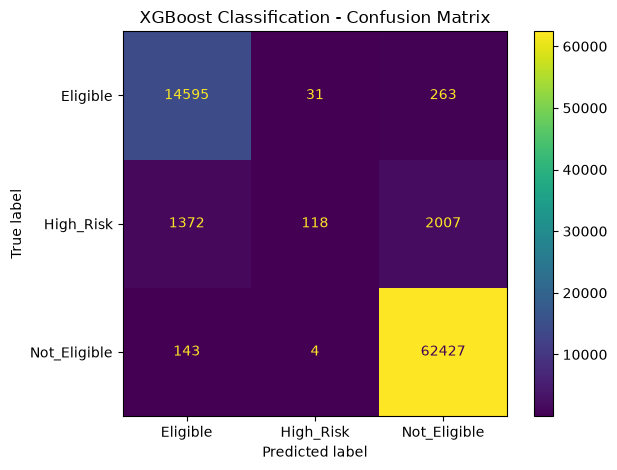

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import mlflow

# Generate predictions
y_pred_xgb_encoded = xgboost_cls.predict(X_test_cls)

# Convert predictions back to original class labels
y_pred_xgb = label_encoder_cls.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

# Create confusion matrix
cm_xgb = confusion_matrix(
    y_test_cls,
    y_pred_xgb,
    labels=["Eligible", "High_Risk", "Not_Eligible"]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Eligible", "High_Risk", "Not_Eligible"]
)

disp.plot()
plt.title("XGBoost Classification - Confusion Matrix")
plt.tight_layout()

# Save image
plt.savefig(
    "xgboost_classification_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [64]:
# Log XGBoost confusion matrix as an MLflow artifact

with mlflow.start_run(run_name="XGBoost_Classification_Artifacts"):

    mlflow.log_artifact(
        "xgboost_classification_confusion_matrix.png"
    )

    print("XGBoost classification confusion matrix logged successfully.")

XGBoost classification confusion matrix logged successfully.


In [65]:
from sklearn.metrics import classification_report
import pandas as pd

# Create classification report
report_xgb = classification_report(
    y_test_cls,
    y_pred_xgb,
    labels=["Eligible", "High_Risk", "Not_Eligible"],
    output_dict=True
)

# Convert report to DataFrame
classification_report_xgb = pd.DataFrame(report_xgb).transpose()

# Save as CSV
classification_report_xgb.to_csv(
    "xgboost_classification_report.csv"
)

print("XGBoost classification report created successfully.")
print(classification_report_xgb)

XGBoost classification report created successfully.
              precision    recall  f1-score       support
Eligible       0.905959  0.980254  0.941643  14889.000000
High_Risk      0.771242  0.033743  0.064658   3497.000000
Not_Eligible   0.964913  0.997651  0.981009  62574.000000
accuracy       0.952816  0.952816  0.952816      0.952816
macro avg      0.880705  0.670549  0.662437  80960.000000
weighted avg   0.945706  0.952816  0.934188  80960.000000


In [66]:
with mlflow.start_run(run_name="XGBoost_Classification_Report"):

    mlflow.log_artifact(
        "xgboost_classification_report.csv"
    )

    print("XGBoost classification report logged successfully.")

XGBoost classification report logged successfully.


In [67]:
import pandas as pd
import numpy as np

# Get the trained XGBoost model from the pipeline
xgb_classifier = xgboost_cls.named_steps["model"]

# Get the fitted preprocessor
fitted_preprocessor = xgboost_cls.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance
importance_values = xgb_classifier.feature_importances_

# Create feature importance DataFrame
feature_importance_xgb = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort by importance
feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 XGBoost Classification Features")
print("---------------------------------------")
print(feature_importance_xgb.head(20))

Top 20 XGBoost Classification Features
---------------------------------------
                                      Feature  Importance
0                      num__disposable_income    0.166125
1                       num__requested_amount    0.093840
2                     cat__existing_loans_Yes    0.070580
3                 num__total_financial_burden    0.057718
4                      cat__existing_loans_No    0.057628
5                       num__requested_tenure    0.053989
6                     num__current_emi_amount    0.041011
7               cat__emi_scenario_Vehicle EMI    0.039329
8   cat__emi_scenario_E-commerce Shopping EMI    0.038495
9                         num__salary_outlier    0.036131
10        cat__emi_scenario_Personal Loan EMI    0.031676
11                          num__credit_score    0.027235
12      cat__emi_scenario_Home Appliances EMI    0.022075
13                num__bank_balance_to_income    0.021082
14                         num__emi_to_income    0.

In [68]:
# Save XGBoost feature importance
feature_importance_xgb.to_csv(
    "xgboost_classification_feature_importance.csv",
    index=False
)

print("Feature importance CSV created successfully.")

Feature importance CSV created successfully.


In [69]:
with mlflow.start_run(run_name="XGBoost_Feature_Importance"):

    mlflow.log_artifact(
        "xgboost_classification_feature_importance.csv"
    )

    print("XGBoost feature importance logged successfully.")

XGBoost feature importance logged successfully.


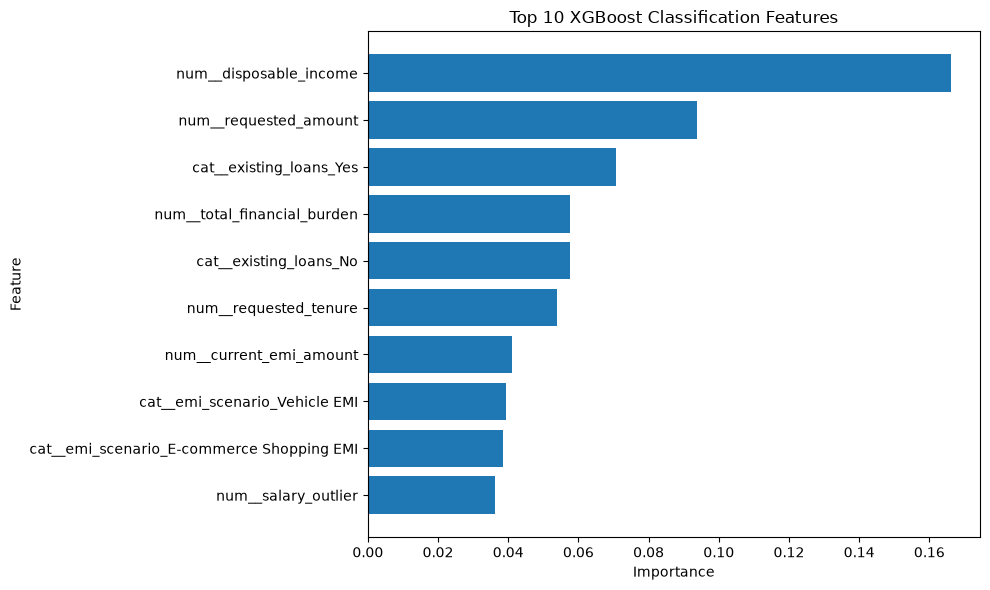

In [70]:
import matplotlib.pyplot as plt

# Select top 10 features
top_10_features = feature_importance_xgb.head(10).sort_values(
    by="Importance",
    ascending=True
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Classification Features")

plt.tight_layout()

# Save chart
plt.savefig(
    "xgboost_top10_feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [71]:
with mlflow.start_run(run_name="XGBoost_Feature_Importance_Chart"):

    mlflow.log_artifact(
        "xgboost_top10_feature_importance.png"
    )

    print("XGBoost feature importance chart logged successfully.")

XGBoost feature importance chart logged successfully.


In [72]:
with mlflow.start_run(run_name="XGBoost_Feature_Importance_Chart"):

    mlflow.log_artifact(
        "xgboost_top10_feature_importance.png"
    )

    print("XGBoost feature importance chart logged successfully.")

XGBoost feature importance chart logged successfully.


In [73]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created successfully.")

Models folder created successfully.


In [74]:
import joblib

joblib.dump(
    xgboost_cls,
    "../models/xgboost_classification_model.pkl"
)

joblib.dump(
    label_encoder_cls,
    "../models/classification_label_encoder.pkl"
)

print("XGBoost classification model saved successfully.")
print("Classification label encoder saved successfully.")

XGBoost classification model saved successfully.
Classification label encoder saved successfully.


In [75]:
joblib.dump(
    xgboost_model,
    "../models/xgboost_regression_model.pkl"
)

print("XGBoost regression model saved successfully.")

XGBoost regression model saved successfully.


In [76]:
import joblib
import os

# Check files exist
model_files = [
    "../models/xgboost_classification_model.pkl",
    "../models/classification_label_encoder.pkl",
    "../models/xgboost_regression_model.pkl"
]

print("Checking saved model files...")
print("--------------------------------")

for file in model_files:
    print(
        f"{os.path.basename(file)} : "
        f"{'Found' if os.path.exists(file) else 'Missing'}"
    )

# Load models
loaded_classification_model = joblib.load(
    "../models/xgboost_classification_model.pkl"
)

loaded_label_encoder = joblib.load(
    "../models/classification_label_encoder.pkl"
)

loaded_regression_model = joblib.load(
    "../models/xgboost_regression_model.pkl"
)

print("\nAll models loaded successfully!")

Checking saved model files...
--------------------------------
xgboost_classification_model.pkl : Found
classification_label_encoder.pkl : Found
xgboost_regression_model.pkl : Found

All models loaded successfully!


In [1]:
from pathlib import Path
import mlflow
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Use SQLite MLflow backend
mlflow_db_path = (PROJECT_ROOT / "mlflow.db").as_posix()
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")

# Use our experiment
mlflow.set_experiment("EMIPredict_AI")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", mlflow.get_experiment_by_name("EMIPredict_AI"))

MLflow tracking URI: sqlite:///c:/Users/ADMIN/Desktop/EMI_Predict AI/mlflow.db
Experiment: <Experiment: artifact_location='file:///C:/Users/ADMIN/Desktop/EMI_Predict AI/mlruns/1', creation_time=1788863801290, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788863801290, lifecycle_stage='active', name='EMIPredict_AI', tags={}, trace_location=None, workspace='default'>


In [2]:
# Recreate MLflow runs with the exact metrics from our model evaluation

import mlflow

# Make sure we are using the SQLite database
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")
mlflow.set_experiment("EMIPredict_AI")


# ============================================================
# 1. CLASSIFICATION MODELS
# ============================================================

classification_runs = [
    {
        "name": "Logistic Regression - Classification",
        "model": "Logistic Regression",
        "accuracy": 0.7876235177865613,
        "precision": 0.9190955568939334,
        "recall": 0.7876235177865613,
        "f1_score": 0.8388017978546193,
        "roc_auc": 0.9564467673982654,
        "params": {
            "max_iter": 1000,
            "class_weight": "balanced"
        }
    },
    {
        "name": "Random Forest - Classification",
        "model": "Random Forest",
        "accuracy": 0.9341403162055336,
        "precision": 0.9232182261630656,
        "recall": 0.9341403162055336,
        "f1_score": 0.9221450969239253,
        "roc_auc": 0.9892700203407695,
        "params": {
            "n_estimators": 100,
            "class_weight": "balanced"
        }
    },
    {
        "name": "XGBoost - Classification",
        "model": "XGBoost",
        "accuracy": 0.9528162055335968,
        "precision": 0.9457058501405986,
        "recall": 0.9528162055335968,
        "f1_score": 0.9341884028204426,
        "roc_auc": 0.9961274921887736,
        "params": {
            "n_estimators": 100,
            "max_depth": 6,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8
        }
    },
    {
        "name": "Balanced XGBoost - Classification",
        "model": "Balanced XGBoost",
        "accuracy": 0.8857213438735178,
        "precision": 0.9624558820205552,
        "recall": 0.8857213438735178,
        "f1_score": 0.9128521025578544,
        "roc_auc": 0.9944470073117067,
        "params": {
            "n_estimators": 100,
            "max_depth": 6,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "class_weighting": "sample_weight"
        }
    }
]


# ============================================================
# 2. REGRESSION MODELS
# ============================================================

regression_runs = [
    {
        "name": "Linear Regression - Regression",
        "model": "Linear Regression",
        "rmse": 4024.9885824926437,
        "mae": 2906.947016179571,
        "r2": 0.7255841743913318,
        "mape": 191.0329682849781,
        "params": {}
    },
    {
        "name": "Random Forest - Regression",
        "model": "Random Forest",
        "rmse": 924.8593152485934,
        "mae": 211.53503716279644,
        "r2": 0.9855112406734221,
        "mape": 5.40861532112095,
        "params": {
            "n_estimators": 100
        }
    },
    {
        "name": "XGBoost - Regression",
        "model": "XGBoost",
        "rmse": 770.3264269718737,
        "mae": 264.4206150052444,
        "r2": 0.9899485332052564,
        "mape": 10.396039225202358,
        "params": {
            "n_estimators": 100,
            "max_depth": 6,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8
        }
    }
]


# ============================================================
# LOG CLASSIFICATION RUNS
# ============================================================

for run_info in classification_runs:

    with mlflow.start_run(run_name=run_info["name"]) as run:

        mlflow.set_tag("task", "classification")
        mlflow.set_tag("model_type", run_info["model"])

        mlflow.log_params(run_info["params"])

        mlflow.log_metrics({
            "accuracy": run_info["accuracy"],
            "precision": run_info["precision"],
            "recall": run_info["recall"],
            "f1_score": run_info["f1_score"],
            "roc_auc": run_info["roc_auc"]
        })

        print(f"Logged: {run_info['name']} | Run ID: {run.info.run_id}")


# ============================================================
# LOG REGRESSION RUNS
# ============================================================

for run_info in regression_runs:

    with mlflow.start_run(run_name=run_info["name"]) as run:

        mlflow.set_tag("task", "regression")
        mlflow.set_tag("model_type", run_info["model"])

        mlflow.log_params(run_info["params"])

        mlflow.log_metrics({
            "rmse": run_info["rmse"],
            "mae": run_info["mae"],
            "r2": run_info["r2"],
            "mape": run_info["mape"]
        })

        print(f"Logged: {run_info['name']} | Run ID: {run.info.run_id}")


print("\n✅ All 7 MLflow runs recreated successfully!")

Logged: Logistic Regression - Classification | Run ID: 17b9fc157da94b46b9acf867d43f697c
Logged: Random Forest - Classification | Run ID: 6f90c499636548e6a781bfd781a71018
Logged: XGBoost - Classification | Run ID: d8c68999821a45c887aca09efa9c5965
Logged: Balanced XGBoost - Classification | Run ID: 304d2694af26422f804d159d235ed708
Logged: Linear Regression - Regression | Run ID: 2b8f37c4681b4cdf8b43d00bd202a809
Logged: Random Forest - Regression | Run ID: 2dc527ad635743a8a7a3edbdfb76e800
Logged: XGBoost - Regression | Run ID: 0206d42610054247a78a68829a4d97f0

✅ All 7 MLflow runs recreated successfully!


In [3]:
print(type(xgboost_cls))
print(type(xgboost_model))

NameError: name 'xgboost_cls' is not defined

In [4]:
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

classification_model_path = PROJECT_ROOT / "models" / "xgboost_classification_model.pkl"
regression_model_path = PROJECT_ROOT / "models" / "xgboost_regression_model.pkl"

xgboost_cls = joblib.load(classification_model_path)
xgboost_model = joblib.load(regression_model_path)

print("Classification model:", type(xgboost_cls))
print("Regression model:", type(xgboost_model))

Classification model: <class 'sklearn.pipeline.Pipeline'>
Regression model: <class 'sklearn.pipeline.Pipeline'>


In [5]:
import mlflow
import mlflow.sklearn

# Make sure we're connected to the SQLite MLflow database
mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

mlflow.set_experiment("EMIPredict_AI")

with mlflow.start_run(run_name="XGBoost Classification - Model Registry") as run:

    # Log the trained pipeline
    model_info = mlflow.sklearn.log_model(
        sk_model=xgboost_cls,
        name="xgboost_classification_model"
    )

    # Add useful metadata
    mlflow.set_tag("task", "classification")
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("purpose", "EMI Eligibility Prediction")

    # Log the final evaluation metrics
    mlflow.log_metrics({
        "accuracy": 0.9528162055335968,
        "precision": 0.9457058501405986,
        "recall": 0.9528162055335968,
        "f1_score": 0.9341884028204426,
        "roc_auc": 0.9961274921887736
    })

    classification_run_id = run.info.run_id

    print("Classification model logged successfully.")
    print("Run ID:", classification_run_id)

MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['numpy.dtype', 'xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier'].

In [6]:
import mlflow
import mlflow.sklearn

# Make sure we're connected to the SQLite MLflow database
mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

mlflow.set_experiment("EMIPredict_AI")

with mlflow.start_run(
    run_name="XGBoost Classification - Model Registry"
) as run:

    model_info = mlflow.sklearn.log_model(
        sk_model=xgboost_cls,
        name="xgboost_classification_model",
        skops_trusted_types=[
            "numpy.dtype",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier"
        ]
    )

    mlflow.set_tag("task", "classification")
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("purpose", "EMI Eligibility Prediction")

    mlflow.log_metrics({
        "accuracy": 0.9528162055335968,
        "precision": 0.9457058501405986,
        "recall": 0.9528162055335968,
        "f1_score": 0.9341884028204426,
        "roc_auc": 0.9961274921887736
    })

    classification_run_id = run.info.run_id

    print("✅ Classification model logged successfully")
    print("Run ID:", classification_run_id)

✅ Classification model logged successfully
Run ID: c7e6822886c9471eb149b81477d2ea43


In [7]:
import mlflow
import mlflow.sklearn

# Connect to SQLite MLflow database
mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

mlflow.set_experiment("EMIPredict_AI")

with mlflow.start_run(
    run_name="XGBoost Regression - Model Registry"
) as run:

    model_info = mlflow.sklearn.log_model(
        sk_model=xgboost_model,
        name="xgboost_regression_model",
        skops_trusted_types=[
            "numpy.dtype",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBRegressor"
        ]
    )

    mlflow.set_tag("task", "regression")
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("purpose", "Maximum Monthly EMI Prediction")

    mlflow.log_metrics({
        "rmse": 770.3264269718737,
        "mae": 264.4206150052444,
        "r2": 0.9899485332052564,
        "mape": 10.396039225202358
    })

    regression_run_id = run.info.run_id

    print("✅ Regression model logged successfully")
    print("Run ID:", regression_run_id)

✅ Regression model logged successfully
Run ID: 46ed06df2c254e1abbb2c4277c403885


In [8]:
import mlflow

mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

classification_model_uri = (
    f"runs:/{classification_run_id}/"
    "xgboost_classification_model"
)

registered_classification = mlflow.register_model(
    model_uri=classification_model_uri,
    name="EMIPredict_Classification_Model"
)

print("✅ Classification model registered")
print("Name:", registered_classification.name)
print("Version:", registered_classification.version)

Successfully registered model 'EMIPredict_Classification_Model'.
2026/09/08 16:27:55 WARNING mlflow.tracking._model_registry.fluent: Run with id c7e6822886c9471eb149b81477d2ea43 has no artifacts at artifact path 'xgboost_classification_model', registering model based on models:/m-91041383175e4f59ab7281aecc2a494b instead


✅ Classification model registered
Name: EMIPredict_Classification_Model
Version: 1


Created version '1' of model 'EMIPredict_Classification_Model'.


In [9]:
import mlflow

mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

regression_model_uri = (
    f"runs:/{regression_run_id}/"
    "xgboost_regression_model"
)

registered_regression = mlflow.register_model(
    model_uri=regression_model_uri,
    name="EMIPredict_Regression_Model"
)

print("✅ Regression model registered")
print("Name:", registered_regression.name)
print("Version:", registered_regression.version)

Successfully registered model 'EMIPredict_Regression_Model'.
2026/09/08 16:28:43 WARNING mlflow.tracking._model_registry.fluent: Run with id 46ed06df2c254e1abbb2c4277c403885 has no artifacts at artifact path 'xgboost_regression_model', registering model based on models:/m-1b4754da00694f57ab8e59325d5bd580 instead


✅ Regression model registered
Name: EMIPredict_Regression_Model
Version: 1


Created version '1' of model 'EMIPredict_Regression_Model'.


In [10]:
from mlflow import MlflowClient

mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path}"
)

client = MlflowClient()

# Get classification model versions
classification_versions = client.search_model_versions(
    "name='EMIPredict_Classification_Model'"
)

# Get regression model versions
regression_versions = client.search_model_versions(
    "name='EMIPredict_Regression_Model'"
)

print("=== Classification Model ===")

for version in classification_versions:
    print(
        "Name:", version.name,
        "| Version:", version.version,
        "| Run ID:", version.run_id
    )

print("\n=== Regression Model ===")

for version in regression_versions:
    print(
        "Name:", version.name,
        "| Version:", version.version,
        "| Run ID:", version.run_id
    )

=== Classification Model ===
Name: EMIPredict_Classification_Model | Version: 1 | Run ID: c7e6822886c9471eb149b81477d2ea43

=== Regression Model ===
Name: EMIPredict_Regression_Model | Version: 1 | Run ID: 46ed06df2c254e1abbb2c4277c403885
